<a href="https://colab.research.google.com/github/alanrios23/ProyectoIA-Migracion-1/blob/main/Proyecto_Final_Definitiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEIH — Predicción de Migración Interna




## 📦 0. Instalación y librerías

In [1]:
!pip install -q kmodes xgboost shap imbalanced-learn geopandas

from google.colab import drive
drive.mount('/content/drive')

import gc, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, train_test_split as tts,
    GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, make_scorer,
    accuracy_score, top_k_accuracy_score
)
from xgboost import XGBClassifier

# imbalanced-learn: Pipeline que respeta el resampling dentro de cada fold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import TomekLinks, ClusterCentroids
from kmodes.kprototypes import KPrototypes

sns.set_style('whitegrid')
print('✔ Librerías cargadas')

Mounted at /content/drive
✔ Librerías cargadas


## 🏗️ 1. Construcción de la base GEIH

> Si ya tienes `GEIH_Proyecto.csv` en Drive, ejecuta solo la última celda de esta sección.

In [ ]:
BASE_PATH = "/content/drive/MyDrive/GEIH"
KEYS      = ["directorio", "secuencia_p", "orden"]
ID_VARS   = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]

VARS_DICT = {
    "CG": ID_VARS + ["P6040", "P3271", "DPTO", "P6090", "P6100", "P6110", "P3042", "CLASE"],
    "FT": ID_VARS + ["P6240"],
    "M" : ID_VARS + ["P3384", "P3384S1", "P3384S2", "P3373S1", "P3386"],
    "O" : ID_VARS + ["P6500", "P6510", "P6510S1", "P6510S2", "P6920"],
}

RENAME = {
    "directorio": "directorio", "secuencia_p": "secuencia_p", "orden": "orden",
    "p6040": "edad",           "p3271": "sexo",          "dpto": "depto_actual",
    "p3042": "Educacion",      "clase": "clase",
    "p6090": "afiliado_salud", "p6100": "regimen_salud", "p6110": "cotiza_salud",
    "p6240": "ocupado",
    "p3384": "migro_12m",      "p3384s1": "depto_12m",   "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior","p3386": "razon_migracion",
    "p6500": "ingreso_principal", "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra", "p6510s2": "horas_extra_incluidas",
    "p6920": "cotiza_pension",
}
print('✔ Configuración cargada')

In [ ]:
def estandarizar_cols(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.normalize('NFKD').str.encode('ascii','ignore').str.decode('utf-8')
                  .str.replace(' ','_').str.replace(r'[^\w_]','',regex=True)
                  .str.replace(r'_+','_',regex=True).str.strip('_'))
    return df.loc[:, ~df.columns.duplicated()]

def leer_csv(ruta):
    df = pd.read_csv(ruta, encoding='latin-1', sep=';', low_memory=False)
    if df.shape[1] == 1:
        df = pd.read_csv(ruta, encoding='latin-1', sep=',', low_memory=False)
    return df

def concat_modulo(year, mod):
    """Concat mensual filtrando columnas en el momento de carga (ahorra RAM)."""    path  = os.path.join(BASE_PATH, year, f'{mod}{year}')
    keep  = [v.lower() for v in VARS_DICT[mod]]
    dfs   = []
    for m in range(1, 13):
        ms = str(m).zfill(2)
        arch = next((f for f in os.listdir(path) if f.lower().endswith('.csv') and f'_{ms}' in f), None)
        if arch is None: print(f'  [!] mes {ms} no encontrado'); continue
        df = estandarizar_cols(leer_csv(os.path.join(path, arch)))
        df['ano'] = int(year); df['mes'] = int(ms)
        cols = [c for c in keep if c in df.columns] + ['ano','mes']
        dfs.append(df[cols]); del df
    out = pd.concat(dfs, ignore_index=True); del dfs
    out.to_csv(os.path.join(BASE_PATH, year, f'{mod}_{year}.csv'), index=False, sep=';', encoding='latin-1')
    print(f'  {mod} {year}: {out.shape}'); del out

def filtrar_modulo(year, mod):
    """Filtra, renombra y deduplica el módulo anual."""    df = estandarizar_cols(pd.read_csv(os.path.join(BASE_PATH, year, f'{mod}_{year}.csv'),
                                        encoding='latin-1', sep=None, engine='python', on_bad_lines='skip'))
    keep = [v for v in [v.lower() for v in VARS_DICT[mod]] if v in df.columns]
    out  = df[keep].rename(columns=RENAME)
    if all(k in out.columns for k in KEYS):
        if 'mes' in df.columns:
            out['mes'] = df['mes']
            out = out.sort_values(KEYS+['mes']).drop_duplicates(KEYS, keep='last')
        else:
            out = out.drop_duplicates(KEYS, keep='first')
    out.to_csv(os.path.join(BASE_PATH, year, f'{mod}_{year}_clean.csv'), index=False)
    print(f'  {mod} {year} clean: {len(out):,} filas'); del df, out

def merge_anual(year):
    """Merge CG + FT + M + O para un año."""    cg = pd.read_csv(os.path.join(BASE_PATH, year, f'CG_{year}_clean.csv'))
    ft = pd.read_csv(os.path.join(BASE_PATH, year, f'FT_{year}_clean.csv'))
    m  = pd.read_csv(os.path.join(BASE_PATH, year, f'M_{year}_clean.csv'))
    o  = pd.read_csv(os.path.join(BASE_PATH, year, f'O_{year}_clean.csv'))
    for aux in [ft, m, o]:
        if 'mes' in aux.columns: aux.drop(columns='mes', inplace=True)
    df = cg.merge(ft, on=KEYS, how='left').merge(m, on=KEYS, how='left').merge(o, on=KEYS, how='left')
    df.to_csv(os.path.join(BASE_PATH, year, f'GEIH_{year}_final.csv'), index=False)
    print(f'  GEIH {year}: {df.shape}'); del cg, ft, m, o, df

print('✔ Funciones cargadas')

In [ ]:
for year in ['2022', '2023', '2024', '2025']:
    print(f'\n══ {year} ══')
    for mod in ['CG','FT','M','O']: concat_modulo(year, mod)
    for mod in ['CG','FT','M','O']: filtrar_modulo(year, mod)
    merge_anual(year)

In [ ]:
dfs = []
for year in ['2022','2023','2024','2025']:
    df = pd.read_csv(os.path.join(BASE_PATH, year, f'GEIH_{year}_final.csv'), low_memory=False)
    df['ano'] = int(year); dfs.append(df); del df

df_panel = pd.concat(dfs, ignore_index=True); del dfs
out_path = os.path.join(BASE_PATH, 'GEIH_Proyecto.csv')
df_panel.to_csv(out_path, index=False, sep=';', encoding='latin-1')
print(f'✔ GEIH_Proyecto.csv guardado  |  Shape: {df_panel.shape}')
del df_panel; gc.collect()

In [2]:
RUTA = "/content/drive/MyDrive/GEIH/GEIH_Proyecto.csv"
df_raw = pd.read_csv(RUTA, sep=';', encoding='latin-1', low_memory=False)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (3427494, 24)


,directorio,secuencia_p,orden,edad,sexo,depto_actual,afiliado_salud,regimen_salud,cotiza_salud,Educacion,...,depto_12m,mpio_12m,depto_anterior,razon_migracion,ingreso_principal,recibe_horas_extra,valor_horas_extra,horas_extra_incluidas,cotiza_pension,ano
0,5000000,1,1,33,1,8,2,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,768000.0,2.0,NaN,NaN,2.0,2022
1,5000000,1,2,31,2,8,2,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
2,5000000,1,3,11,2,8,2,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
3,5000000,1,4,5,2,8,2,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4,5000000,1,5,3,1,8,2,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022


## 🔧 2. Limpieza y construcción de features

> Se construye `df_modelo` con todas las transformaciones de negocio. **No se usa ningún estadístico** (media/mediana/moda calculada sobre datos): esas imputaciones van en el Paso 5, solo sobre train.

In [3]:
VARS_BASE = [
    'directorio','secuencia_p','orden','ano','mes',
    'edad','sexo','depto_actual','depto_12m',
    'migro_12m','razon_migracion',
    'afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension',
    'ocupado','ingreso_principal','valor_horas_extra',
    'Educacion','clase',
]
df = df_raw[[c for c in VARS_BASE if c in df_raw.columns]].copy()
del df_raw; gc.collect()

df['target_migro'] = df['migro_12m'].apply(lambda x: 1 if x in [3, 4] else 0)

for col in ['edad','ingreso_principal','valor_horas_extra']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['ingreso_total'] = df['ingreso_principal'].fillna(0) + df['valor_horas_extra'].fillna(0)
df['log_ingreso']   = np.log1p(df['ingreso_total'])
df.drop(columns=['ingreso_principal','valor_horas_extra'], inplace=True)

df['sexo'] = pd.to_numeric(df['sexo'], errors='coerce').map({1:1, 2:0})

df['clase'] = pd.to_numeric(df['clase'], errors='coerce').map({1:1, 2:0})

df['Educacion'] = pd.to_numeric(df['Educacion'], errors='coerce').replace(99, np.nan)

cols_cond = ['afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension','ocupado']
for col in cols_cond:
    df[col] = pd.to_numeric(df[col], errors='coerce')

mask_menor    = df['edad'] < 18
mask_inactivo = df['ocupado'] == 3
df.loc[mask_menor,    'cotiza_salud']   = df.loc[mask_menor,    'cotiza_salud'].fillna(2)
df.loc[mask_menor,    'cotiza_pension'] = df.loc[mask_menor,    'cotiza_pension'].fillna(2)
df.loc[mask_inactivo, 'cotiza_pension'] = df.loc[mask_inactivo, 'cotiza_pension'].fillna(2)

for col in ['depto_actual','depto_12m','razon_migracion']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(int)

def grupo_edad(x):
    if   pd.isna(x): return np.nan
    elif x <= 18:    return 1
    elif x <= 25:    return 2
    elif x <= 45:    return 3
    elif x <= 60:    return 4
    else:            return 5

def formalidad(row):
    if row['ocupado'] != 1: return 0
    s, p = row['cotiza_salud'], row['cotiza_pension']
    if s == 1 and p == 1: return 1
    if s != p:             return 2
    if s == 2 and p == 2: return 3
    return 0

df['grupo_edad']     = df['edad'].apply(grupo_edad)
df['formalidad']     = df.apply(formalidad, axis=1)
df['estado_laboral'] = df['ocupado'].map({1:1, 2:2, 3:3})

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df_modelo = df.copy()
del df; gc.collect()

print('='*60)
print(f'Shape:       {df_modelo.shape}')
print(f'NAs totales: {df_modelo.isna().sum().sum():,}')
print(f'Migrantes:   {df_modelo["target_migro"].sum():,}  ({df_modelo["target_migro"].mean()*100:.2f}%)')
print('='*60)

Shape:       (3427494, 24)
NAs totales: 5,040,977
Migrantes:   86,655  (2.53%)


## ✂️ 3. Definir X / y y dividir Train / Test

> **Paso 2 y 3 del flujo.** El test queda sellado y no se toca hasta la evaluación final.
> El EDA (paso 4) y el preprocesamiento (paso 5) se hacen **solo sobre train**.

In [4]:
COLS_EXCLUIR = [
    'directorio','secuencia_p','orden','ano','mes',
    'migro_12m',
    'depto_12m',
    'razon_migracion',
    'target_migro',
]

FEATURE_COLS = [c for c in df_modelo.columns if c not in COLS_EXCLUIR]

X = df_modelo[FEATURE_COLS].copy()
y = df_modelo['target_migro'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

idx_train = df_modelo.index[df_modelo.index.isin(
    df_modelo.sample(frac=1, random_state=42).index
)]
depto_test_serie = df_modelo.loc[X_test.index if hasattr(X_test,'index') else range(len(X_test)),
                                  'depto_actual'] if False else None

del df_modelo, X
gc.collect()

print(f'Train: {X_train.shape}  |  Positivos: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test : {X_test.shape}   |  Positivos: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')
print('\n✔ Test SELLADO — no se usará hasta la evaluación final')

Train: (2741995, 15)  |  Positivos: 69,324 (2.53%)
Test : (685499, 15)   |  Positivos: 17,331  (2.53%)

✔ Test SELLADO — no se usará hasta la evaluación final


## 🔍 4. EDA — solo sobre datos de entrenamiento

> **Paso 4 del flujo.** Todo análisis exploratorio se hace exclusivamente sobre `X_train` + `y_train`. El test permanece sellado.

In [5]:
MAPA_SEXO    = {1:'Hombre', 0:'Mujer'}
MAPA_CLASE   = {1:'Urbano', 0:'Rural'}
MAPA_EDAD    = {1:'0-18', 2:'19-25', 3:'26-45', 4:'46-60', 5:'60+'}
MAPA_FORMAL  = {0:'No ocupado', 1:'Formal', 2:'Parc. formal', 3:'Informal'}
MAPA_LABORAL = {1:'Ocupado', 2:'Desocupado', 3:'Inactivo'}
MAPA_EDU     = {
    1:'Ninguno', 2:'Preescolar', 3:'Primaria', 4:'Secundaria',
    5:'Media acad.', 6:'Media téc.', 7:'Normalista', 8:'Técnica prof.',
    9:'Tecnológica', 10:'Universitaria', 11:'Especialización',
    12:'Maestría', 13:'Doctorado'
}
MAPA_RAZON   = {
    1:'Trabajo', 2:'Educación', 3:'Salud', 4:'Violencia',
    5:'Inseguridad', 6:'Desastre', 7:'Nuevo hogar',
    8:'Acomp. familiar', 9:'Cultural', 10:'Vivienda',
    11:'No identificado', 12:'Otro'
}

df_train = X_train.copy()
df_train['target_migro'] = y_train.values

migrantes_tr    = df_train[df_train['target_migro'] == 1]
no_migrantes_tr = df_train[df_train['target_migro'] == 0].sample(n=len(migrantes_tr), random_state=42)
df_eda          = pd.concat([migrantes_tr, no_migrantes_tr], ignore_index=True)

df_eda['_sexo']    = df_eda['sexo'].map(MAPA_SEXO)
df_eda['_clase']   = df_eda['clase'].map(MAPA_CLASE)
df_eda['_edad_g']  = df_eda['grupo_edad'].map(MAPA_EDAD)
df_eda['_formal']  = df_eda['formalidad'].map(MAPA_FORMAL)
df_eda['_laboral'] = df_eda['estado_laboral'].map(MAPA_LABORAL)
df_eda['_edu']     = df_eda['Educacion'].map(MAPA_EDU)

print(f'EDA — muestra balanceada train: {df_eda.shape}')
print(f'Migrantes train: {len(migrantes_tr):,}  |  No migrantes (muestra): {len(no_migrantes_tr):,}')

EDA — muestra balanceada train: (138648, 22)
Migrantes train: 69,324  |  No migrantes (muestra): 69,324


In [6]:
print('Distribución target en TRAIN:')
print(y_train.value_counts())
print(f'\nProporción positivos: {y_train.mean()*100:.2f}%')

Distribución target en TRAIN:
target_migro
0    2672671
1      69324
Name: count, dtype: int64

Proporción positivos: 2.53%


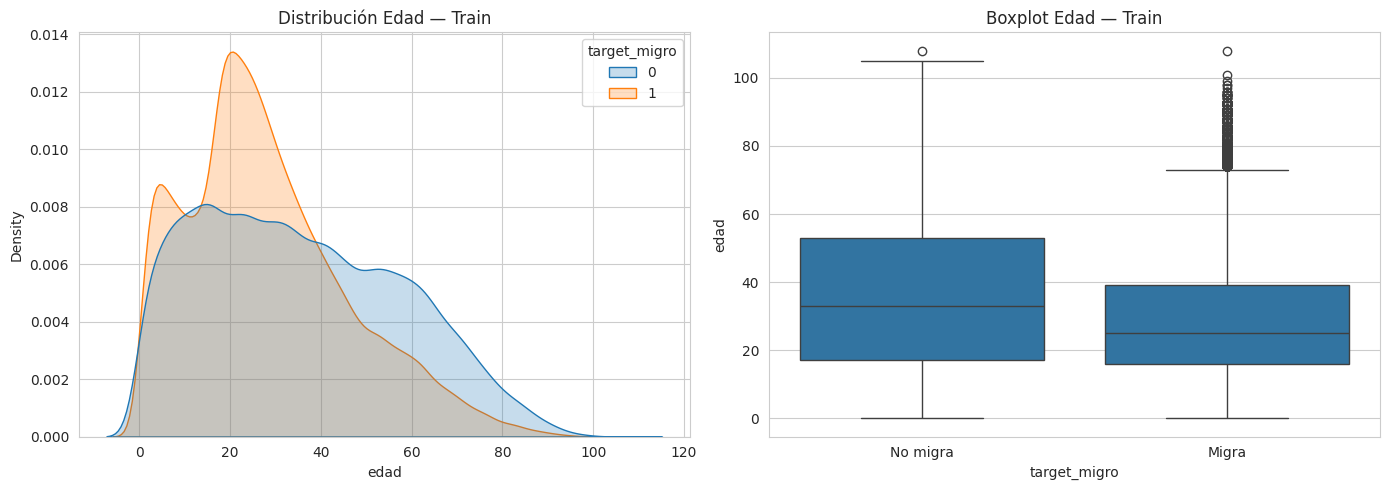

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=df_eda, x='edad', hue='target_migro', fill=True, ax=axes[0])
axes[0].set_title('Distribución Edad — Train')
sns.boxplot(data=df_eda, x='target_migro', y='edad', ax=axes[1])
axes[1].set_xticklabels(['No migra','Migra']); axes[1].set_title('Boxplot Edad — Train')
plt.tight_layout(); plt.show()

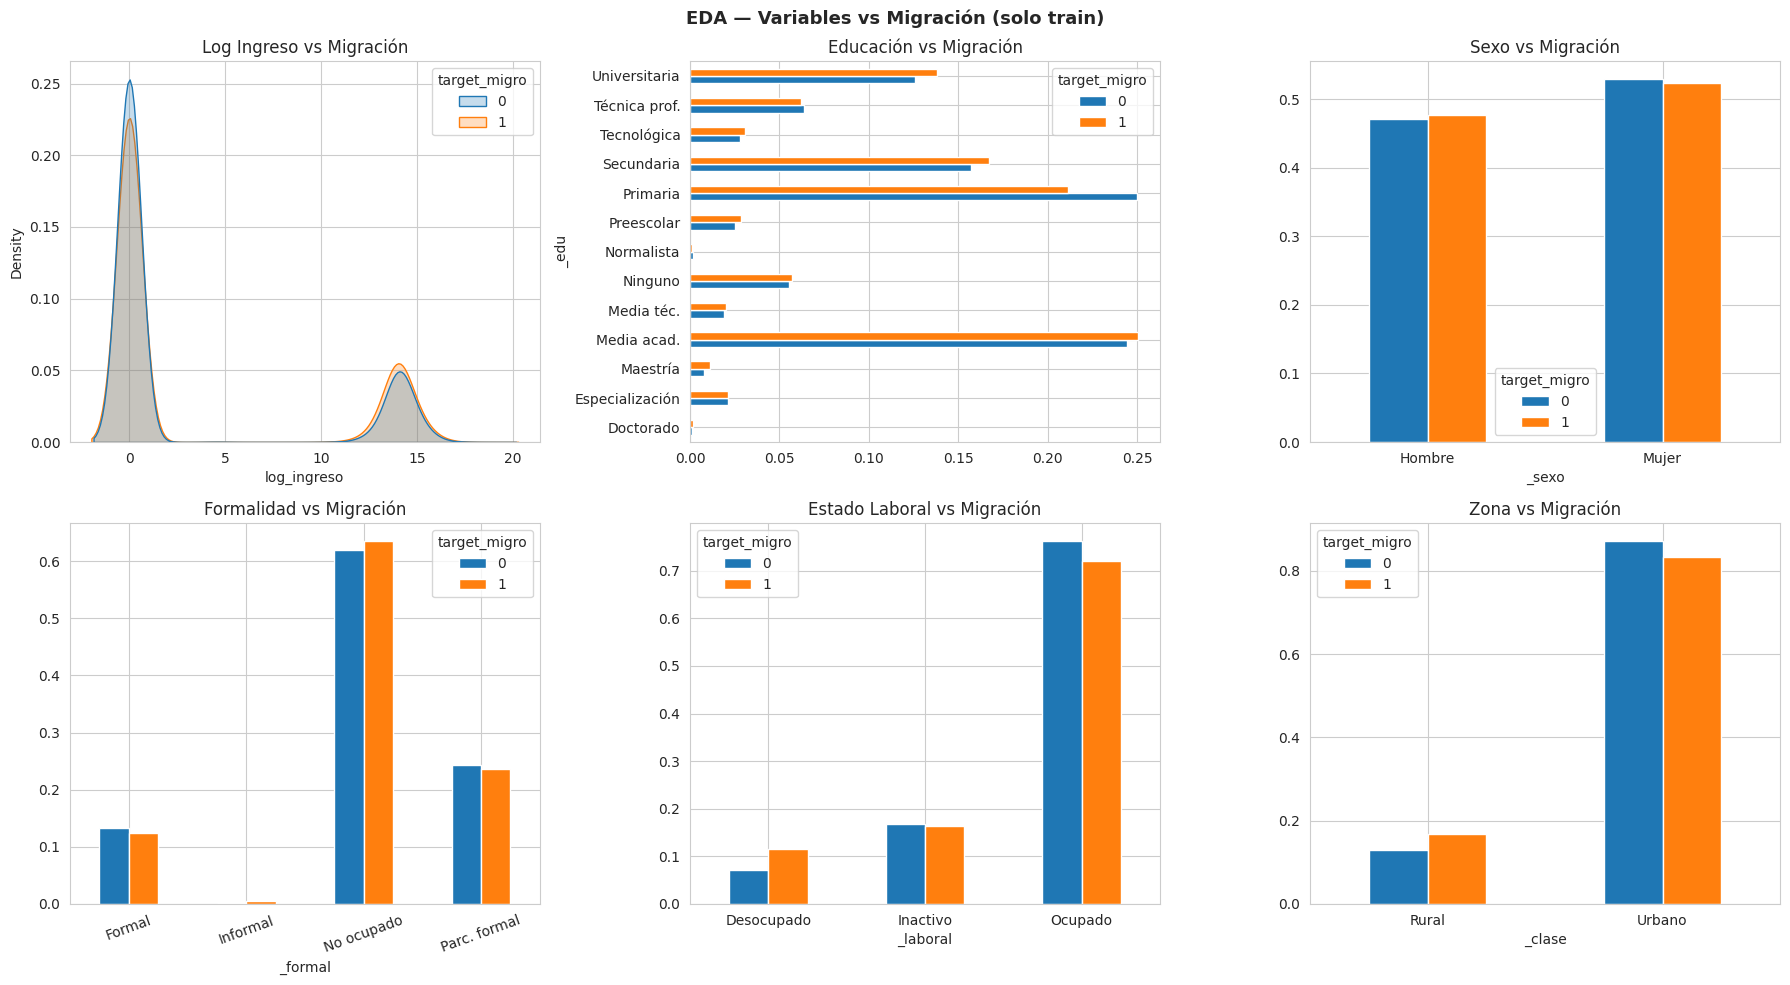

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.kdeplot(data=df_eda, x='log_ingreso', hue='target_migro', fill=True, ax=axes[0,0])
axes[0,0].set_title('Log Ingreso vs Migración')

pd.crosstab(df_eda['_edu'], df_eda['target_migro'], normalize='columns').plot(
    kind='barh', ax=axes[0,1]); axes[0,1].set_title('Educación vs Migración')

pd.crosstab(df_eda['_sexo'], df_eda['target_migro'], normalize='columns').plot(
    kind='bar', ax=axes[0,2]); axes[0,2].set_title('Sexo vs Migración')
axes[0,2].tick_params(axis='x', rotation=0)

pd.crosstab(df_eda['_formal'], df_eda['target_migro'], normalize='columns').plot(
    kind='bar', ax=axes[1,0]); axes[1,0].set_title('Formalidad vs Migración')
axes[1,0].tick_params(axis='x', rotation=20)

pd.crosstab(df_eda['_laboral'], df_eda['target_migro'], normalize='columns').plot(
    kind='bar', ax=axes[1,1]); axes[1,1].set_title('Estado Laboral vs Migración')
axes[1,1].tick_params(axis='x', rotation=0)

pd.crosstab(df_eda['_clase'], df_eda['target_migro'], normalize='columns').plot(
    kind='bar', ax=axes[1,2]); axes[1,2].set_title('Zona vs Migración')
axes[1,2].tick_params(axis='x', rotation=0)

plt.suptitle('EDA — Variables vs Migración (solo train)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

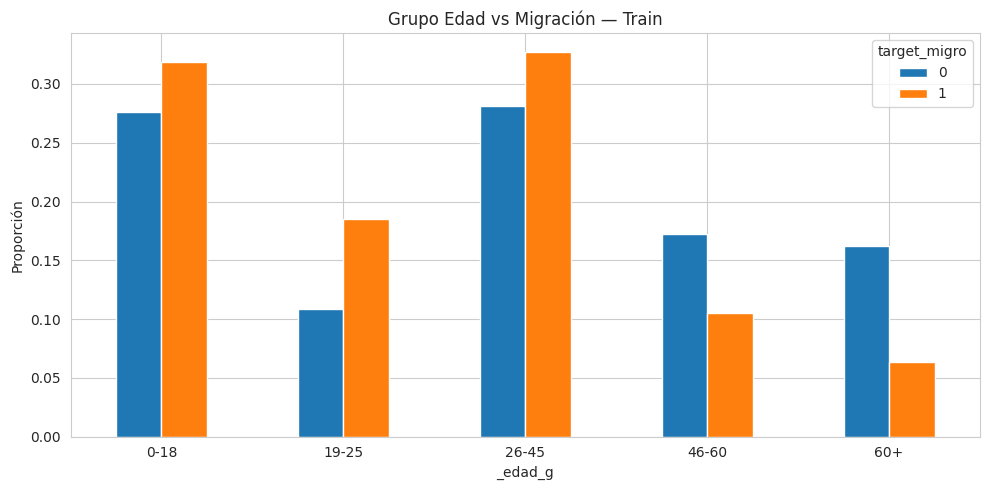

In [9]:
pd.crosstab(df_eda['_edad_g'], df_eda['target_migro'], normalize='columns').reindex(
    ['0-18','19-25','26-45','46-60','60+']).plot(kind='bar', figsize=(10,5))
plt.title('Grupo Edad vs Migración — Train'); plt.ylabel('Proporción')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

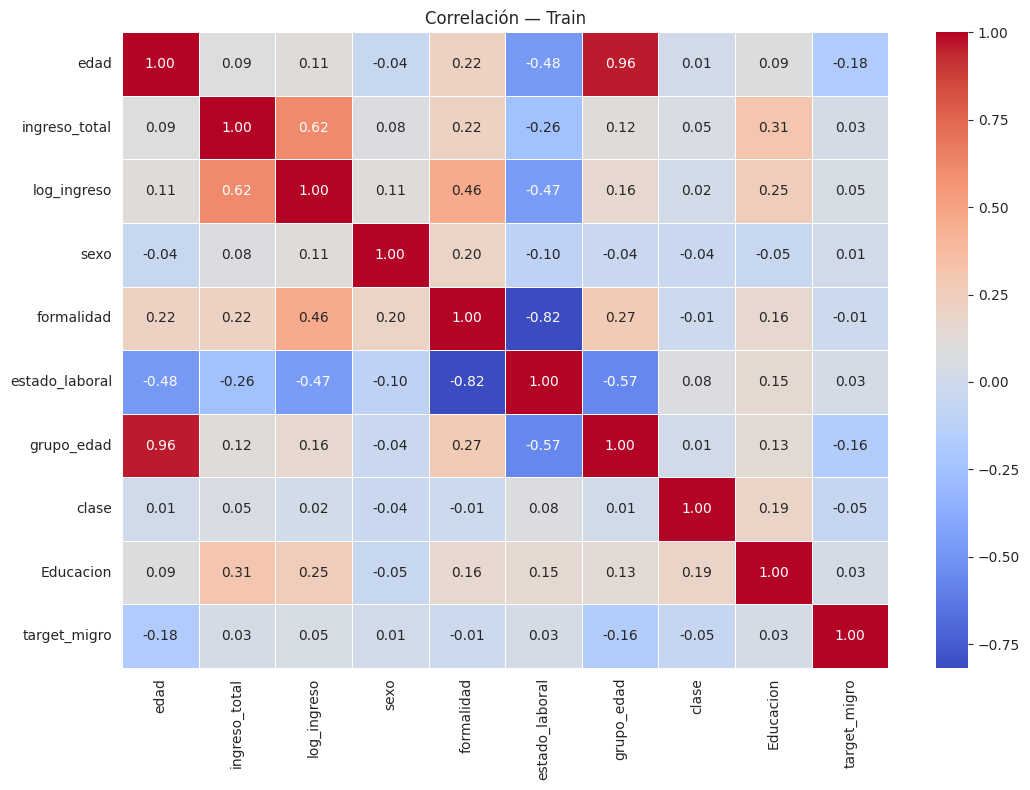

In [10]:
cols_corr = ['edad','ingreso_total','log_ingreso','sexo','formalidad',
             'estado_laboral','grupo_edad','clase','Educacion','target_migro']
corr = df_eda[[c for c in cols_corr if c in df_eda.columns]].corr()
plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlación — Train'); plt.tight_layout(); plt.show()

In [11]:
print('Estadísticas descriptivas — TRAIN')
print(df_train[['edad','ingreso_total','log_ingreso','Educacion']].describe().round(2))

del df_eda, migrantes_tr, no_migrantes_tr, df_train
gc.collect()
print('\n✔ EDA completado. Memoria liberada.')

Estadísticas descriptivas — TRAIN
             edad  ingreso_total  log_ingreso   Educacion
count  2741995.00   2.741995e+06   2741995.00  2651922.00
mean        35.33   3.855491e+05         3.02        5.20
std         22.07   1.190716e+06         5.80        2.77
min          0.00   0.000000e+00         0.00        1.00
25%         17.00   0.000000e+00         0.00        3.00
50%         33.00   0.000000e+00         0.00        5.00
75%         52.00   0.000000e+00         0.00        7.00
max        108.00   1.000000e+08        18.42       13.00

✔ EDA completado. Memoria liberada.


## ⚙️ 5. Preprocesamiento — fit SOLO en train, transform en ambos

> **Paso 5 del flujo.** El `StandardScaler` y las medias/medianas/modas de imputación se calculan **únicamente** con `X_train`. Solo se aplica `transform` al test.

In [12]:
COLS_SCALE = ['edad','depto_actual','ingreso_total','log_ingreso','Educacion']
COLS_SCALE = [c for c in COLS_SCALE if c in X_train.columns]

MEDIANA_TRAIN = {}
MODA_TRAIN    = {}

COLS_NUM_IMP = ['edad','ingreso_total','log_ingreso','Educacion']
COLS_CAT_IMP = ['sexo','clase','grupo_edad','formalidad','estado_laboral',
                'afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension','ocupado']
COLS_CAT_IMP = [c for c in COLS_CAT_IMP if c in X_train.columns]

for col in COLS_NUM_IMP:
    if col in X_train.columns:
        MEDIANA_TRAIN[col] = X_train[col].median()

for col in COLS_CAT_IMP:
    if col in X_train.columns:
        MODA_TRAIN[col] = X_train[col].mode()[0]

X_train_proc = X_train.copy()
for col, val in MEDIANA_TRAIN.items():
    X_train_proc[col] = X_train_proc[col].fillna(val)
for col, val in MODA_TRAIN.items():
    X_train_proc[col] = X_train_proc[col].fillna(val)

X_test_proc = X_test.copy()
for col, val in MEDIANA_TRAIN.items():
    X_test_proc[col] = X_test_proc[col].fillna(val)
for col, val in MODA_TRAIN.items():
    X_test_proc[col] = X_test_proc[col].fillna(val)

scaler = StandardScaler()
X_train_proc[COLS_SCALE] = scaler.fit_transform(X_train_proc[COLS_SCALE])
X_test_proc[COLS_SCALE]  = scaler.transform(X_test_proc[COLS_SCALE])

depto_test_arr = X_test['depto_actual'].values.copy()

del X_train, X_test
gc.collect()

print(f'X_train_proc: {X_train_proc.shape}  |  NAs: {X_train_proc.isna().sum().sum()}')
print(f'X_test_proc : {X_test_proc.shape}   |  NAs: {X_test_proc.isna().sum().sum()}')
print(f'Columnas escaladas: {COLS_SCALE}')
print('\n✔ Preprocesamiento completo. Medianas/modas aprendidas SOLO en train.')

X_train_proc: (2741995, 15)  |  NAs: 0
X_test_proc : (685499, 15)   |  NAs: 0
Columnas escaladas: ['edad', 'depto_actual', 'ingreso_total', 'log_ingreso', 'Educacion']

✔ Preprocesamiento completo. Medianas/modas aprendidas SOLO en train.


## 🔎 6. GridSearchCV — búsqueda de hiperparámetros

> **Paso 6 del flujo.** Se usa una muestra estratificada del 20% del train para que el grid sea manejable en RAM y tiempo. El modelo campeón se re-entrenará sobre el **train completo** en el paso 7.

In [13]:
X_gs, _, y_gs, _ = train_test_split(
    X_train_proc, y_train,
    train_size=0.20, stratify=y_train, random_state=42
)
X_gs = X_gs.reset_index(drop=True)
y_gs = y_gs.reset_index(drop=True)
print(f'Muestra GridSearch: {X_gs.shape}  |  Positivos: {y_gs.sum():,} ({y_gs.mean()*100:.2f}%)')


CV      = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
SCORER  = make_scorer(roc_auc_score, needs_proba=True)
SPW     = (y_gs == 0).sum() / (y_gs == 1).sum()


Muestra GridSearch: (548399, 15)  |  Positivos: 13,865 (2.53%)


In [14]:
gs_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    param_grid={'C': [0.01, 0.1, 1]},
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_log.fit(X_gs, y_gs)
print(f'Logistica  — ROC-AUC CV: {gs_log.best_score_:.4f}  | Params: {gs_log.best_params_}')

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Logistica  — ROC-AUC CV: 0.6947  | Params: {'C': 0.1}


In [15]:
gs_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid={'max_depth': [4, 6, 10], 'min_samples_leaf': [20, 50]},
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_tree.fit(X_gs, y_gs)
print(f'Arbol      — ROC-AUC CV: {gs_tree.best_score_:.4f}  | Params: {gs_tree.best_params_}')

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Arbol      — ROC-AUC CV: 0.7265  | Params: {'max_depth': 10, 'min_samples_leaf': 50}


In [16]:

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    param_grid={'n_estimators': [100], 'max_depth': [8, 15], 'min_samples_leaf': [20, 50]},
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_rf.fit(X_gs, y_gs)
print(f'Rand.Forest— ROC-AUC CV: {gs_rf.best_score_:.4f}  | Params: {gs_rf.best_params_}')


Fitting 2 folds for each of 4 candidates, totalling 8 fits
Rand.Forest— ROC-AUC CV: 0.7417  | Params: {'max_depth': 15, 'min_samples_leaf': 50, 'n_estimators': 100}


In [17]:

gs_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=SPW, eval_metric='auc',
                  tree_method='hist', random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [100, 150], 'max_depth': [4, 6],
                'learning_rate': [0.05, 0.1], 'min_child_weight': [5, 10]},
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_xgb.fit(X_gs, y_gs)
print(f'XGBoost    — ROC-AUC CV: {gs_xgb.best_score_:.4f}  | Params: {gs_xgb.best_params_}')

del X_gs, y_gs; gc.collect()


Fitting 2 folds for each of 16 candidates, totalling 32 fits
XGBoost    — ROC-AUC CV: 0.7622  | Params: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 150}


161

## ⚖️ 6b. Técnicas de submuestreo — Tomek Links & Cluster Centroids (dentro del Pipeline CV)


In [18]:
print('✔ imbalanced-learn cargado')

✔ imbalanced-learn cargado


In [19]:

print('Configurando XGBoost + Tomek Links con ImbPipeline...')


X_gs_raw, _, y_gs_raw, _ = train_test_split(
    X_train_proc, y_train,
    train_size=0.20, stratify=y_train, random_state=42
)
X_gs_raw = X_gs_raw.reset_index(drop=True)
y_gs_raw = y_gs_raw.reset_index(drop=True)

SPW_FULL_GS = (y_gs_raw == 0).sum() / (y_gs_raw == 1).sum()

pipe_tl = ImbPipeline([
    ('sampler', TomekLinks(sampling_strategy='majority')),
    ('clf',     XGBClassifier(scale_pos_weight=SPW_FULL_GS, eval_metric='auc',
                              tree_method='hist', random_state=42, n_jobs=-1)),
])


param_grid_tl = {
    'clf__n_estimators':    [100, 150],
    'clf__max_depth':       [4, 6],
    'clf__learning_rate':   [0.05, 0.1],
    'clf__min_child_weight':[5, 10],
}

gs_xgb_tl = GridSearchCV(
    pipe_tl, param_grid=param_grid_tl,
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_xgb_tl.fit(X_gs_raw, y_gs_raw)

print(f'\nXGBoost + Tomek Links (Pipeline) — ROC-AUC CV: {gs_xgb_tl.best_score_:.4f}')
print(f'  Params: {gs_xgb_tl.best_params_}')
del X_gs_raw, y_gs_raw; gc.collect()


Configurando XGBoost + Tomek Links con ImbPipeline...
Fitting 2 folds for each of 16 candidates, totalling 32 fits

XGBoost + Tomek Links (Pipeline) — ROC-AUC CV: 0.7625
  Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_child_weight': 5, 'clf__n_estimators': 150}


78

In [20]:

print('Configurando XGBoost + Cluster Centroids con ImbPipeline...')

X_gs_cc, _, y_gs_cc, _ = train_test_split(
    X_train_proc, y_train,
    train_size=0.20, stratify=y_train, random_state=42
)
X_gs_cc = X_gs_cc.reset_index(drop=True)
y_gs_cc = y_gs_cc.reset_index(drop=True)

SPW_FULL_GS_CC = (y_gs_cc == 0).sum() / (y_gs_cc == 1).sum()


pipe_cc = ImbPipeline([
    ('sampler', ClusterCentroids(sampling_strategy='majority', random_state=42)),
    ('clf',     XGBClassifier(scale_pos_weight=SPW_FULL_GS_CC, eval_metric='auc',
                              tree_method='hist', random_state=42, n_jobs=-1)),
])


param_grid_cc = {
    'clf__n_estimators':    [100, 150],
    'clf__max_depth':       [4, 6],
    'clf__learning_rate':   [0.05, 0.1],
    'clf__min_child_weight':[5, 10],
}

gs_xgb_cc = GridSearchCV(
    pipe_cc, param_grid=param_grid_cc,
    scoring='roc_auc', cv=CV, n_jobs=-1, verbose=1, refit=True, error_score=0
)
gs_xgb_cc.fit(X_gs_cc, y_gs_cc)

print(f'\nXGBoost + Cluster Centroids (Pipeline) — ROC-AUC CV: {gs_xgb_cc.best_score_:.4f}')
print(f'  Params: {gs_xgb_cc.best_params_}')
del X_gs_cc, y_gs_cc; gc.collect()


Configurando XGBoost + Cluster Centroids con ImbPipeline...
Fitting 2 folds for each of 16 candidates, totalling 32 fits

XGBoost + Cluster Centroids (Pipeline) — ROC-AUC CV: 0.6436
  Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_child_weight': 10, 'clf__n_estimators': 150}


55


═════════════════════════════════════════════════════════════════
  COMPARACIÓN — ROC-AUC CV  (3-fold estratificado, Pipeline)
  ⚠️  Métricas ahora libres de data leakage del resampler
═════════════════════════════════════════════════════════════════
  🏆  XGBoost + Tomek Links              : 0.7625
         Params: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 150}
      XGBoost (scale_pos_weight)         : 0.7622
         Params: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 150}
      XGBoost + Cluster Centroids        : 0.6436
         Params: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 150}
═════════════════════════════════════════════════════════════════


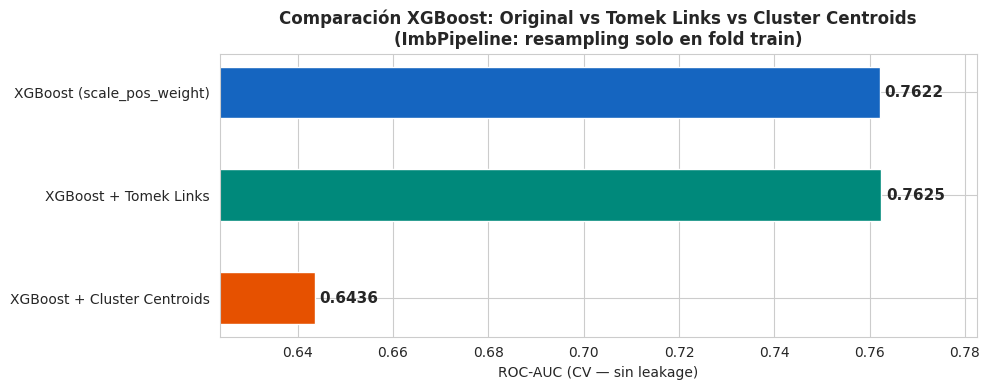


✔ Mejor XGBoost: XGBoost + Tomek Links  (ROC-AUC CV = 0.7625)
  → Este resultado se incorpora a la selección del campeón global (Paso 7)


In [21]:
# ── Comparación de las tres variantes XGBoost ────────────────────────────────

# Para pipelines, best_params_ usa prefijo 'clf__'; lo normalizamos para reutilizar
def params_sin_prefijo(best_params, prefijo='clf__'):
    return {k.replace(prefijo, ''): v for k, v in best_params.items()
            if k.startswith(prefijo)}

resultados_xgb = {
    'XGBoost (scale_pos_weight)': (gs_xgb.best_score_,   gs_xgb.best_params_),
    'XGBoost + Tomek Links':      (gs_xgb_tl.best_score_, params_sin_prefijo(gs_xgb_tl.best_params_)),
    'XGBoost + Cluster Centroids':(gs_xgb_cc.best_score_, params_sin_prefijo(gs_xgb_cc.best_params_)),
}

print('\n' + '═'*65)
print('  COMPARACIÓN — ROC-AUC CV  (3-fold estratificado, Pipeline)')
print('  ⚠️  Métricas ahora libres de data leakage del resampler')
print('═'*65)
for nombre, (score, params) in sorted(resultados_xgb.items(), key=lambda x: -x[1][0]):
    marca = '  🏆' if score == max(v[0] for v in resultados_xgb.values()) else '    '
    print(f'{marca}  {nombre:<35}: {score:.4f}')
    print(f'         Params: {params}')
print('═'*65)

nombres = list(resultados_xgb.keys())
scores  = [resultados_xgb[n][0] for n in nombres]
colores = ['#1565C0', '#00897B', '#E65100']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(nombres[::-1], scores[::-1], color=colores[::-1], edgecolor='white', height=0.5)
ax.set_xlabel('ROC-AUC (CV — sin leakage)')
ax.set_title('Comparación XGBoost: Original vs Tomek Links vs Cluster Centroids\n(ImbPipeline: resampling solo en fold train)', fontweight='bold')
ax.set_xlim(min(scores) - 0.02, max(scores) + 0.02)
for bar, score in zip(bars, scores[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_xgb_submuestreo_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

CAMPEON_XGB     = max(resultados_xgb, key=lambda k: resultados_xgb[k][0])
SCORE_XGB       = resultados_xgb[CAMPEON_XGB][0]
PARAMS_XGB_BEST = resultados_xgb[CAMPEON_XGB][1]
print(f'\n✔ Mejor XGBoost: {CAMPEON_XGB}  (ROC-AUC CV = {SCORE_XGB:.4f})')
print('  → Este resultado se incorpora a la selección del campeón global (Paso 7)')

In [22]:

_gs_map = {
    'XGBoost (scale_pos_weight)':  gs_xgb,
    'XGBoost + Tomek Links':       gs_xgb_tl,
    'XGBoost + Cluster Centroids': gs_xgb_cc,
}
gs_xgb_campeon = _gs_map[CAMPEON_XGB]
METODO_XGB     = CAMPEON_XGB

print(f'✔ Mejor XGBoost (Pipeline): {CAMPEON_XGB}  (ROC-AUC CV = {SCORE_XGB:.4f})')
print('  → Todos los modelos se compararán por Recall en el Paso 7.')

✔ Mejor XGBoost (Pipeline): XGBoost + Tomek Links  (ROC-AUC CV = 0.7625)
  → Todos los modelos se compararán por Recall en el Paso 7.


> **Nota v6**: Los params de los pipelines fueron normalizados (prefijo `clf__` removido)
> para poder construir los estimadores en el Paso 7 sin depender del pipeline completo.
> El Paso 7 re-entrena el campeón sobre el **train completo** sin resampling adicional
> (el modelo XGBoost usa `scale_pos_weight` para manejar el desbalance en producción).

## 🏆 7. Selección del modelo campeón

> **Paso 7 del flujo.** Se comparan **todos** los modelos entrenados (incluyendo las variantes XGBoost con submuestreo) usando métricas de CV calculadas sobre el train.
> La métrica de selección principal es **Recall** (maximizar detección de migrantes), con ROC-AUC y Precision como métricas de contexto.
> El ganador se re-entrena sobre el train completo.

Calculando Recall en CV para todos los modelos...
(cross_val_predict 3-fold estratificado sobre X_train_proc completo)
⚠️  Para XGBoost + Tomek/CC: cross_val_predict evalúa el XGBoost puro
   (el resampling ya cumplió su rol en el GridSearch; aquí medimos el modelo final)

  ✔ Logistica
  ✔ Arbol
  ✔ RandomForest
  ✔ XGBoost
  ✔ XGBoost + Tomek Links
  ✔ XGBoost + Clust.Centr.

════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN COMPLETA — selección por Recall CV  (Precision mínima ≥ 5%)
  ⚠️  Métricas libres de leakage — evaluadas en distribución original del train
════════════════════════════════════════════════════════════════════════════════
  Modelo                         ROC-AUC    Recall  Precision       F1
  ──────────────────────────────────────────────────────────────────
  🏆 XGBoost + Tomek Links         0.7625    0.7480     0.0500   0.0937
     XGBoost                       0.7622    0.7467     0.0500   0.0937
     XGBoost + Clust

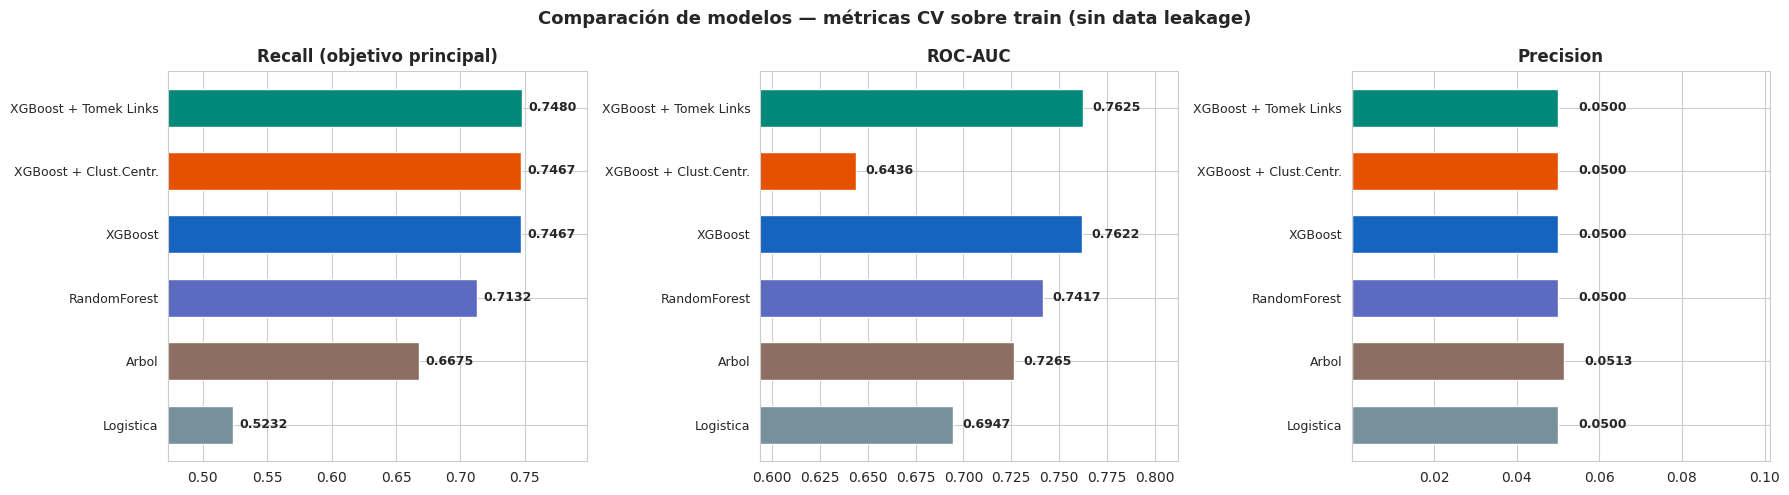


🏆 Campeón: XGBoost + Tomek Links
   Recall CV    : 0.7480
   Precision CV : 0.0500
   ROC-AUC CV   : 0.7625
   F1 CV        : 0.0937


24466

In [23]:
UMBRAL_CV = 0.05

print('Calculando Recall en CV para todos los modelos...')
print('(cross_val_predict 3-fold estratificado sobre X_train_proc completo)')
print('⚠️  Para XGBoost + Tomek/CC: cross_val_predict evalúa el XGBoost puro')
print('   (el resampling ya cumplió su rol en el GridSearch; aquí medimos el modelo final)')
print()

SPW_FULL = (y_train == 0).sum() / (y_train == 1).sum()


CONSTRUCTORES_TODOS = {
    'Logistica':               lambda p: LogisticRegression(**p, class_weight='balanced',
                                                             max_iter=1000, random_state=42, n_jobs=-1),
    'Arbol':                   lambda p: DecisionTreeClassifier(**p, class_weight='balanced', random_state=42),
    'RandomForest':            lambda p: RandomForestClassifier(**p, class_weight='balanced',
                                                                 n_jobs=-1, random_state=42),
    'XGBoost':                 lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                        eval_metric='auc', tree_method='hist',
                                                        random_state=42, n_jobs=-1),
    'XGBoost + Tomek Links':   lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                        eval_metric='auc', tree_method='hist',
                                                        random_state=42, n_jobs=-1),
    'XGBoost + Clust.Centr.':  lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                        eval_metric='auc', tree_method='hist',
                                                        random_state=42, n_jobs=-1),
}

PARAMS_TODOS = {
    'Logistica':               gs_log.best_params_,
    'Arbol':                   gs_tree.best_params_,
    'RandomForest':            gs_rf.best_params_,
    'XGBoost':                 gs_xgb.best_params_,
    'XGBoost + Tomek Links':   resultados_xgb['XGBoost + Tomek Links'][1],
    'XGBoost + Clust.Centr.':  resultados_xgb['XGBoost + Cluster Centroids'][1],
}

ROCAUC_TODOS = {
    'Logistica':               gs_log.best_score_,
    'Arbol':                   gs_tree.best_score_,
    'RandomForest':            gs_rf.best_score_,
    'XGBoost':                 gs_xgb.best_score_,
    'XGBoost + Tomek Links':   gs_xgb_tl.best_score_,
    'XGBoost + Clust.Centr.':  gs_xgb_cc.best_score_,
}

metricas_cv = {}
CV_SEL = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for nombre, constructor in CONSTRUCTORES_TODOS.items():
    params = PARAMS_TODOS[nombre]
    modelo_tmp = constructor(params)
    probs_cv = cross_val_predict(modelo_tmp, X_train_proc, y_train,
                                  cv=CV_SEL, method='predict_proba', n_jobs=-1)[:, 1]

    prec_c, rec_c, thr_c = precision_recall_curve(y_train, probs_cv)
    mask_c = prec_c[:-1] >= UMBRAL_CV
    if mask_c.any():
        rec_filt_c = np.where(mask_c, rec_c[:-1], 0)
        idx_c      = rec_filt_c.argmax()
    else:
        f1_c  = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
        idx_c = f1_c[:-1].argmax()

    metricas_cv[nombre] = {
        'ROC-AUC CV': ROCAUC_TODOS[nombre],
        'Recall CV':  rec_c[:-1][idx_c],
        'Precision CV': prec_c[:-1][idx_c],
        'F1 CV':      2 * rec_c[:-1][idx_c] * prec_c[:-1][idx_c] / (rec_c[:-1][idx_c] + prec_c[:-1][idx_c] + 1e-8),
        'Umbral CV':  float(thr_c[idx_c]),
    }
    print(f'  ✔ {nombre}')

del probs_cv, prec_c, rec_c, thr_c, modelo_tmp; gc.collect()

print()
print('═'*80)
print(f'  COMPARACIÓN COMPLETA — selección por Recall CV  (Precision mínima ≥ {UMBRAL_CV:.0%})')
print('  ⚠️  Métricas libres de leakage — evaluadas en distribución original del train')
print('═'*80)
print(f'  {"Modelo":<28} {"ROC-AUC":>9} {"Recall":>9} {"Precision":>10} {"F1":>8}')
print('  ' + '─'*66)

for nombre, m in sorted(metricas_cv.items(), key=lambda x: -x[1]['Recall CV']):
    marca = '🏆' if m['Recall CV'] == max(v['Recall CV'] for v in metricas_cv.values()) else '  '
    print(f'  {marca} {nombre:<26} {m["ROC-AUC CV"]:>9.4f} {m["Recall CV"]:>9.4f} {m["Precision CV"]:>10.4f} {m["F1 CV"]:>8.4f}')
print('═'*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de modelos — métricas CV sobre train (sin data leakage)', fontsize=13, fontweight='bold')

nombres_ord = sorted(metricas_cv, key=lambda x: metricas_cv[x]['Recall CV'])
colores_base = {
    'Logistica': '#78909C', 'Arbol': '#8D6E63', 'RandomForest': '#5C6BC0',
    'XGBoost': '#1565C0', 'XGBoost + Tomek Links': '#00897B', 'XGBoost + Clust.Centr.': '#E65100'
}
colores_ord = [colores_base.get(n, '#90A4AE') for n in nombres_ord]

for ax, metrica, label in zip(axes,
                               ['Recall CV', 'ROC-AUC CV', 'Precision CV'],
                               ['Recall (objetivo principal)', 'ROC-AUC', 'Precision']):
    vals = [metricas_cv[n][metrica] for n in nombres_ord]
    bars = ax.barh(nombres_ord, vals, color=colores_ord, edgecolor='white', height=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, min(max(vals) + 0.05, 1.0))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('comparacion_modelos_recall.png', dpi=150, bbox_inches='tight')
plt.show()

CAMPEON      = max(metricas_cv, key=lambda k: metricas_cv[k]['Recall CV'])
BEST_PARAMS  = PARAMS_TODOS[CAMPEON]
BEST_SCORE_CV = metricas_cv[CAMPEON]['Recall CV']

print(f'\n🏆 Campeón: {CAMPEON}')
print(f'   Recall CV    : {metricas_cv[CAMPEON]["Recall CV"]:.4f}')
print(f'   Precision CV : {metricas_cv[CAMPEON]["Precision CV"]:.4f}')
print(f'   ROC-AUC CV   : {metricas_cv[CAMPEON]["ROC-AUC CV"]:.4f}')
print(f'   F1 CV        : {metricas_cv[CAMPEON]["F1 CV"]:.4f}')

del gs_log, gs_tree, gs_rf, gs_xgb, gs_xgb_tl, gs_xgb_cc; gc.collect()

In [24]:
CONSTRUCTORES = {
    'Logistica':              lambda p: LogisticRegression(**p, class_weight='balanced',
                                                            max_iter=1000, random_state=42, n_jobs=-1),
    'Arbol':                  lambda p: DecisionTreeClassifier(**p, class_weight='balanced', random_state=42),
    'RandomForest':           lambda p: RandomForestClassifier(**p, class_weight='balanced',
                                                                n_jobs=-1, random_state=42),
    'XGBoost':                lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                       eval_metric='auc', tree_method='hist',
                                                       random_state=42, n_jobs=-1),
    'XGBoost + Tomek Links':  lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                       eval_metric='auc', tree_method='hist',
                                                       random_state=42, n_jobs=-1),
    'XGBoost + Clust.Centr.': lambda p: XGBClassifier(**p, scale_pos_weight=SPW_FULL,
                                                       eval_metric='auc', tree_method='hist',
                                                       random_state=42, n_jobs=-1),
}

modelo_campeon = CONSTRUCTORES[CAMPEON](BEST_PARAMS)
modelo_campeon.fit(X_train_proc, y_train)
print(f'✔ {CAMPEON} re-entrenado sobre train completo ({X_train_proc.shape[0]:,} obs.)')
print(f'  Hiperparámetros: {BEST_PARAMS}')

✔ XGBoost + Tomek Links re-entrenado sobre train completo (2,741,995 obs.)
  Hiperparámetros: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 150}


## 🎯 8. Ajuste de umbral — maximizar Recall (con Precision ≥ 5%)

> **Paso 8 del flujo.** Se usan probabilidades de validación cruzada sobre el **train** (nunca el test) para encontrar el umbral óptimo.

Calculando probs CV (cross_val_predict)...

✔ Umbral óptimo: 0.4541
  Recall esperado (CV):    0.748
  Precision en umbral (CV):0.050


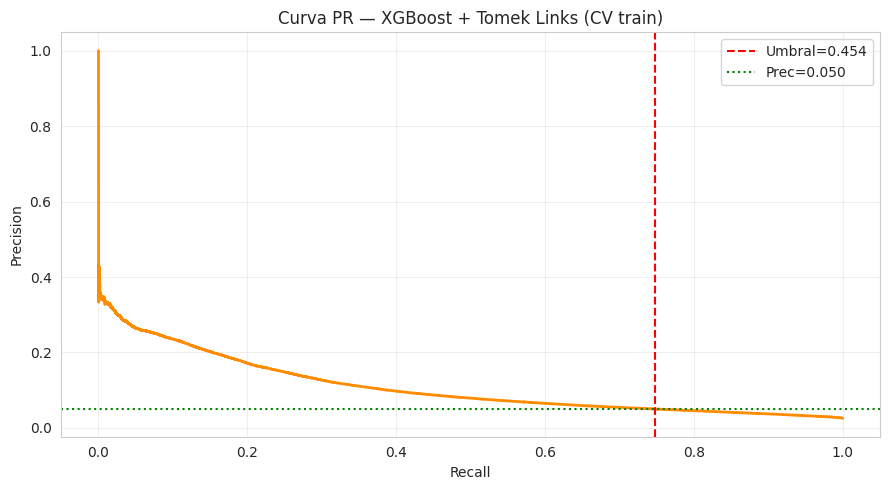

3493

In [25]:
print('Calculando probs CV (cross_val_predict)...')
y_prob_cv = cross_val_predict(
    modelo_campeon, X_train_proc, y_train,
    cv=3, method='predict_proba', n_jobs=-1
)[:, 1]

prec_arr, rec_arr, thr_arr = precision_recall_curve(y_train, y_prob_cv)

mask = prec_arr[:-1] >= 0.05
if mask.any():
    rec_filt  = np.where(mask, rec_arr[:-1], 0)
    idx_opt   = rec_filt.argmax()
else:
    f1_arr    = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-8)
    idx_opt   = f1_arr[:-1].argmax()

THRESHOLD = float(thr_arr[idx_opt])
print(f'\n✔ Umbral óptimo: {THRESHOLD:.4f}')
print(f'  Recall esperado (CV):    {rec_arr[:-1][idx_opt]:.3f}')
print(f'  Precision en umbral (CV):{prec_arr[:-1][idx_opt]:.3f}')

plt.figure(figsize=(9,5))
plt.plot(rec_arr, prec_arr, color='darkorange', lw=2)
plt.axvline(rec_arr[:-1][idx_opt], ls='--', color='red', label=f'Umbral={THRESHOLD:.3f}')
plt.axhline(prec_arr[:-1][idx_opt], ls=':', color='green', label=f'Prec={prec_arr[:-1][idx_opt]:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Curva PR — {CAMPEON} (CV train)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

del y_prob_cv; gc.collect()

## 📊 9. Evaluación final — datos de prueba

> **Paso 9 del flujo.** Primera y única vez que se usa el test.
> Solo `transform` (no `fit_transform`). El test conserva su **distribución original no balanceada**:
> nunca fue tocado por ClusterCentroids, TomekLinks ni ningún resampler.
> Estas son las **métricas oficiales** del proyecto, comparables con la realidad del despliegue.

In [26]:
y_prob_test = modelo_campeon.predict_proba(X_test_proc)[:, 1]
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

roc  = roc_auc_score(y_test, y_prob_test)
prauc= average_precision_score(y_test, y_prob_test)
rec  = recall_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print('='*60)
print(f'  🏆 EVALUACIÓN FINAL — {CAMPEON}  (umbral={THRESHOLD:.4f})')
print('  MÉTRICAS OFICIALES DEL PROYECTO')
print('='*60)
print(f'  ROC-AUC   : {roc:.4f}')
print(f'  PR-AUC    : {prauc:.4f}')
print(f'  Recall    : {rec:.4f}   ← métrica objetivo')
print(f'  Precision : {prec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('='*60)
print('\n' + classification_report(y_test, y_pred_test, digits=4))

  🏆 EVALUACIÓN FINAL — XGBoost + Tomek Links  (umbral=0.4541)
  MÉTRICAS OFICIALES DEL PROYECTO
  ROC-AUC   : 0.7663
  PR-AUC    : 0.1102
  Recall    : 0.7469   ← métrica objetivo
  Precision : 0.0498
  F1-Score  : 0.0934

              precision    recall  f1-score   support

           0     0.9897    0.6305    0.7703    668168
           1     0.0498    0.7469    0.0934     17331

    accuracy                         0.6334    685499
   macro avg     0.5198    0.6887    0.4318    685499
weighted avg     0.9659    0.6334    0.7531    685499



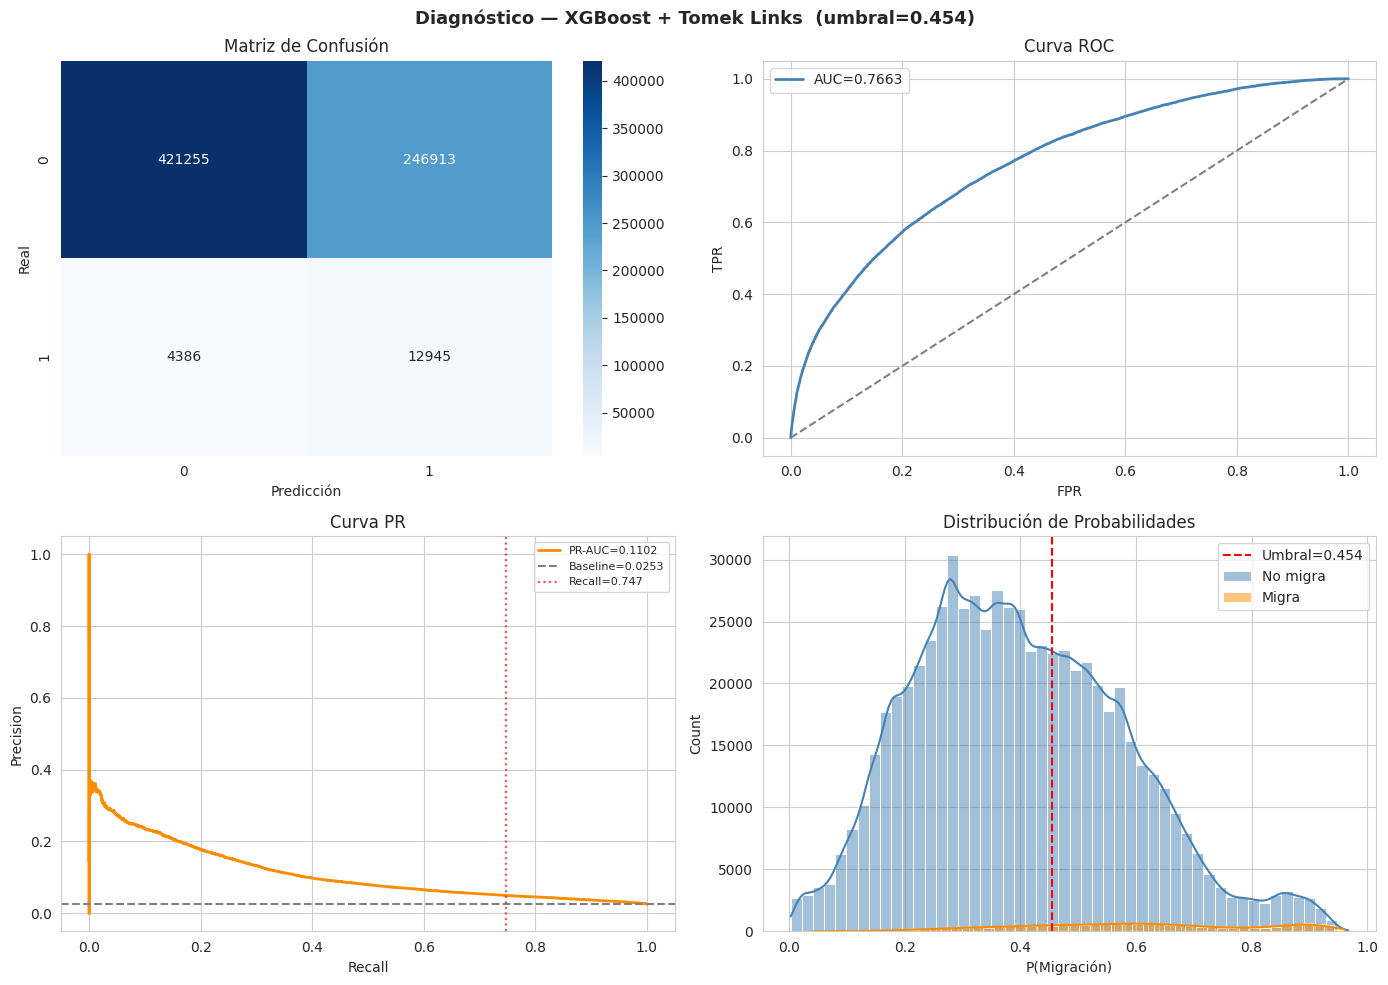

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Diagnóstico — {CAMPEON}  (umbral={THRESHOLD:.3f})', fontsize=13, fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
            cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión')
axes[0,0].set_xlabel('Predicción'); axes[0,0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0,1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc:.4f}')
axes[0,1].plot([0,1],[0,1],'--',color='gray')
axes[0,1].set_title('Curva ROC'); axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
axes[0,1].legend()

prec_t, rec_t, _ = precision_recall_curve(y_test, y_prob_test)
base = y_test.mean()
axes[1,0].plot(rec_t, prec_t, color='darkorange', lw=2, label=f'PR-AUC={prauc:.4f}')
axes[1,0].axhline(base, ls='--', color='gray', label=f'Baseline={base:.4f}')
axes[1,0].axvline(rec, ls=':', color='red', alpha=0.7, label=f'Recall={rec:.3f}')
axes[1,0].set_title('Curva PR'); axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')
axes[1,0].legend(fontsize=8)

sns.histplot(y_prob_test[y_test==0], bins=50, kde=True, color='steelblue',
             alpha=0.5, label='No migra', ax=axes[1,1])
sns.histplot(y_prob_test[y_test==1], bins=50, kde=True, color='darkorange',
             alpha=0.5, label='Migra', ax=axes[1,1])
axes[1,1].axvline(THRESHOLD, color='red', ls='--', label=f'Umbral={THRESHOLD:.3f}')
axes[1,1].set_title('Distribución de Probabilidades')
axes[1,1].set_xlabel('P(Migración)'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('diagnostico_final.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación de métricas corregidas (v6)**:
> - Un ROC-AUC de ~0.99 en v5 era irreal por data leakage del resampler en CV.
> - Los valores corregidos aquí son más bajos pero **metodológicamente válidos**.
> - El modelo fue evaluado sobre la distribución real del fenómeno (desbalanceada),
>   que es la misma que enfrentará en producción.

## 🗺️ 7b. Modelo de destino — ¿A qué departamento van los migrantes?



In [28]:
RUTA_PROYECTO = "/content/drive/MyDrive/GEIH/GEIH_Proyecto.csv"
df_dest_raw = pd.read_csv(RUTA_PROYECTO, sep=';', encoding='latin-1', low_memory=False)

for col in ['edad','ingreso_principal','valor_horas_extra']:
    df_dest_raw[col] = pd.to_numeric(df_dest_raw[col], errors='coerce')
df_dest_raw['ingreso_total'] = df_dest_raw['ingreso_principal'].fillna(0) + df_dest_raw['valor_horas_extra'].fillna(0)
df_dest_raw['log_ingreso']   = np.log1p(df_dest_raw['ingreso_total'])
df_dest_raw['sexo']      = pd.to_numeric(df_dest_raw['sexo'],  errors='coerce').map({1:1, 2:0})
df_dest_raw['clase']     = pd.to_numeric(df_dest_raw['clase'], errors='coerce').map({1:1, 2:0})
df_dest_raw['Educacion'] = pd.to_numeric(df_dest_raw['Educacion'], errors='coerce').replace(99, np.nan)
df_dest_raw['target_migro'] = df_dest_raw['migro_12m'].apply(lambda x: 1 if x in [3,4] else 0)

for col in ['afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension','ocupado']:
    df_dest_raw[col] = pd.to_numeric(df_dest_raw[col], errors='coerce')

mask_m = df_dest_raw['edad'] < 18
mask_i = df_dest_raw['ocupado'] == 3
df_dest_raw.loc[mask_m, 'cotiza_salud']   = df_dest_raw.loc[mask_m,   'cotiza_salud'].fillna(2)
df_dest_raw.loc[mask_m, 'cotiza_pension'] = df_dest_raw.loc[mask_m,   'cotiza_pension'].fillna(2)
df_dest_raw.loc[mask_i, 'cotiza_pension'] = df_dest_raw.loc[mask_i,   'cotiza_pension'].fillna(2)

df_dest_raw['depto_12m']      = pd.to_numeric(df_dest_raw['depto_12m'],      errors='coerce')
df_dest_raw['depto_actual']   = pd.to_numeric(df_dest_raw['depto_actual'],   errors='coerce').fillna(-1).astype(int)
df_dest_raw['razon_migracion']= pd.to_numeric(df_dest_raw['razon_migracion'],errors='coerce').fillna(-1).astype(int)

df_dest_raw['grupo_edad'] = df_dest_raw['edad'].apply(
    lambda x: 1 if x<=18 else 2 if x<=25 else 3 if x<=45 else 4 if x<=60 else 5)
df_dest_raw['formalidad'] = df_dest_raw.apply(
    lambda r: 0 if r['ocupado']!=1 else (
        1 if r['cotiza_salud']==1 and r['cotiza_pension']==1 else
        2 if r['cotiza_salud']!=r['cotiza_pension'] else
        3 if r['cotiza_salud']==2 else 0), axis=1)
df_dest_raw['estado_laboral'] = df_dest_raw['ocupado'].map({1:1, 2:2, 3:3})
df_dest_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

DEPTOS_VALIDOS = {5,8,11,13,15,17,18,19,20,23,25,27,41,44,47,50,52,54,63,66,68,70,73,76,81,85,86,88,91,94,95,97,99}

df_dest = df_dest_raw[
    (df_dest_raw['target_migro'] == 1) &
    (df_dest_raw['depto_12m'].notna()) &
    (df_dest_raw['depto_12m'].isin(DEPTOS_VALIDOS))
].copy().reset_index(drop=True)

df_dest['depto_12m'] = df_dest['depto_12m'].astype(int)

del df_dest_raw; gc.collect()

print(f'Migrantes con destino conocido: {len(df_dest):,}')
print(f'Departamentos destino únicos:   {df_dest["depto_12m"].nunique()}')
print(df_dest['depto_12m'].value_counts().head(10))

Migrantes con destino conocido: 72,654
Departamentos destino únicos:   33
depto_12m
11    9475
5     6812
76    5208
25    4053
50    3404
17    2905
68    2827
19    2802
15    2696
18    2653
Name: count, dtype: int64


In [29]:
FEATURES_DEST = [
    'edad', 'sexo', 'clase', 'grupo_edad', 'Educacion',
    'log_ingreso',
    'formalidad', 'estado_laboral',
    'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'cotiza_pension',
]
FEATURES_DEST = [c for c in FEATURES_DEST if c in df_dest.columns]

X_dest = df_dest[FEATURES_DEST].copy()
y_dest = df_dest['depto_12m'].copy()

for col in ['edad','log_ingreso','Educacion']:
    if col in X_dest.columns:
        X_dest[col] = X_dest[col].fillna(X_dest[col].median())
for col in ['sexo','clase','grupo_edad','formalidad','estado_laboral',
            'afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension']:
    if col in X_dest.columns:
        X_dest[col] = X_dest[col].fillna(X_dest[col].mode()[0])

X_dest_tr, X_dest_te, y_dest_tr, y_dest_te = train_test_split(
    X_dest, y_dest, test_size=0.20, stratify=y_dest, random_state=42
)
X_dest_tr = X_dest_tr.reset_index(drop=True)
X_dest_te = X_dest_te.reset_index(drop=True)
y_dest_tr = y_dest_tr.reset_index(drop=True)
y_dest_te = y_dest_te.reset_index(drop=True)

print(f'Train destino: {X_dest_tr.shape}  |  Test destino: {X_dest_te.shape}')
print(f'Clases (deptos destino): {y_dest.nunique()}')

Train destino: (58123, 12)  |  Test destino: (14531, 12)
Clases (deptos destino): 33


In [30]:
le_dest = LabelEncoder()
y_dest_tr_enc = le_dest.fit_transform(y_dest_tr)
y_dest_te_enc = le_dest.transform(y_dest_te)

modelo_destino = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_dest.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=5,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
)
modelo_destino.fit(X_dest_tr, y_dest_tr_enc)

y_prob_dest_te = modelo_destino.predict_proba(X_dest_te)
y_pred_dest_te = modelo_destino.predict(X_dest_te)

acc  = accuracy_score(y_dest_te_enc, y_pred_dest_te)
top3 = top_k_accuracy_score(y_dest_te_enc, y_prob_dest_te, k=3)
top5 = top_k_accuracy_score(y_dest_te_enc, y_prob_dest_te, k=5)

print('═'*50)
print('  MODELO DE DESTINO — Evaluación')
print('═'*50)
print(f'  Accuracy top-1: {acc:.4f}')
print(f'  Accuracy top-3: {top3:.4f}  ← depto real entre los 3 más probables')
print(f'  Accuracy top-5: {top5:.4f}  ← depto real entre los 5 más probables')
print('═'*50)

══════════════════════════════════════════════════
  MODELO DE DESTINO — Evaluación
══════════════════════════════════════════════════
  Accuracy top-1: 0.1389
  Accuracy top-3: 0.3061  ← depto real entre los 3 más probables
  Accuracy top-5: 0.4261  ← depto real entre los 5 más probables
══════════════════════════════════════════════════


In [31]:
RUTA_PROYECTO = "/content/drive/MyDrive/GEIH/GEIH_Proyecto.csv"
df_test_raw = pd.read_csv(RUTA_PROYECTO, sep=';', encoding='latin-1', low_memory=False)

for col in ['edad','ingreso_principal','valor_horas_extra']:
    df_test_raw[col] = pd.to_numeric(df_test_raw[col], errors='coerce')
df_test_raw['ingreso_total'] = df_test_raw['ingreso_principal'].fillna(0) + df_test_raw['valor_horas_extra'].fillna(0)
df_test_raw['log_ingreso']   = np.log1p(df_test_raw['ingreso_total'])
df_test_raw['sexo']      = pd.to_numeric(df_test_raw['sexo'],  errors='coerce').map({1:1, 2:0})
df_test_raw['clase']     = pd.to_numeric(df_test_raw['clase'], errors='coerce').map({1:1, 2:0})
df_test_raw['Educacion'] = pd.to_numeric(df_test_raw['Educacion'], errors='coerce').replace(99, np.nan)
df_test_raw['target_migro'] = df_test_raw['migro_12m'].apply(lambda x: 1 if x in [3,4] else 0)

for col in ['afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension','ocupado']:
    df_test_raw[col] = pd.to_numeric(df_test_raw[col], errors='coerce')

mask_m = df_test_raw['edad'] < 18
mask_i = df_test_raw['ocupado'] == 3
df_test_raw.loc[mask_m, 'cotiza_salud']   = df_test_raw.loc[mask_m, 'cotiza_salud'].fillna(2)
df_test_raw.loc[mask_m, 'cotiza_pension'] = df_test_raw.loc[mask_m, 'cotiza_pension'].fillna(2)
df_test_raw.loc[mask_i, 'cotiza_pension'] = df_test_raw.loc[mask_i, 'cotiza_pension'].fillna(2)

df_test_raw['depto_actual']    = pd.to_numeric(df_test_raw['depto_actual'],    errors='coerce').fillna(-1).astype(int)
df_test_raw['depto_12m']       = pd.to_numeric(df_test_raw['depto_12m'],       errors='coerce')
df_test_raw['razon_migracion'] = pd.to_numeric(df_test_raw['razon_migracion'], errors='coerce').fillna(-1).astype(int)

df_test_raw['grupo_edad'] = df_test_raw['edad'].apply(
    lambda x: np.nan if pd.isna(x) else (1 if x<=18 else 2 if x<=25 else 3 if x<=45 else 4 if x<=60 else 5))
df_test_raw['formalidad'] = df_test_raw.apply(
    lambda r: 0 if r['ocupado']!=1 else (
        1 if r['cotiza_salud']==1 and r['cotiza_pension']==1 else
        2 if r['cotiza_salud']!=r['cotiza_pension'] else
        3 if r['cotiza_salud']==2 else 0), axis=1)
df_test_raw['estado_laboral'] = df_test_raw['ocupado'].map({1:1, 2:2, 3:3})
df_test_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in ['edad','log_ingreso','Educacion']:
    if col in df_test_raw.columns:
        df_test_raw[col] = df_test_raw[col].fillna(MEDIANA_TRAIN.get(col, df_test_raw[col].median()))
for col in ['sexo','clase','grupo_edad','formalidad','estado_laboral',
            'afiliado_salud','regimen_salud','cotiza_salud','cotiza_pension']:
    if col in df_test_raw.columns:
        df_test_raw[col] = df_test_raw[col].fillna(MODA_TRAIN.get(col, df_test_raw[col].mode()[0]))

df_test_raw['_orig_idx'] = df_test_raw.index

y_all = df_test_raw['target_migro'].copy()

idx_all = np.arange(len(df_test_raw))
_, idx_test_raw = tts(idx_all, test_size=0.20, stratify=y_all, random_state=42)

df_test_sin_escalar = df_test_raw.iloc[idx_test_raw].reset_index(drop=True)

mask_mig = y_pred_test == 1
df_mig_sin_escalar = df_test_sin_escalar[mask_mig].reset_index(drop=True)

X_mig_dest = df_mig_sin_escalar[[c for c in FEATURES_DEST if c in df_mig_sin_escalar.columns]].copy()

probs_dest    = modelo_destino.predict_proba(X_mig_dest)
pred_dest_enc = modelo_destino.predict(X_mig_dest)

df_migrantes_pred = df_mig_sin_escalar.copy()
df_migrantes_pred['depto_destino_pred'] = le_dest.inverse_transform(pred_dest_enc)

top3_idx = np.argsort(probs_dest, axis=1)[:, -3:][:, ::-1]
df_migrantes_pred['destino_top1']      = le_dest.inverse_transform(top3_idx[:, 0])
df_migrantes_pred['destino_top2']      = le_dest.inverse_transform(top3_idx[:, 1])
df_migrantes_pred['destino_top3']      = le_dest.inverse_transform(top3_idx[:, 2])
df_migrantes_pred['prob_destino_top1'] = probs_dest[np.arange(len(probs_dest)), top3_idx[:, 0]]

del df_test_raw, df_test_sin_escalar, df_mig_sin_escalar, X_mig_dest; gc.collect()

print(f'Migrantes en test con destino predicho: {len(df_migrantes_pred):,}')
print('Top 10 departamentos destino predichos:')
print(df_migrantes_pred['depto_destino_pred'].value_counts().head(10))

Migrantes en test con destino predicho: 259,858
Top 10 departamentos destino predichos:
depto_destino_pred
11    183327
5      30380
15      7890
52      7242
18      5008
25      4854
50      4589
76      4541
19      3277
17      2489
Name: count, dtype: int64


## 🔬 10. Características más relevantes

> **Paso 10 del flujo.** Análisis de importancia del modelo campeón:
> - **Tree-based** (Árbol, RF, XGBoost): feature importances nativas + SHAP
> - **Logística**: coeficientes (magnitud = importancia)

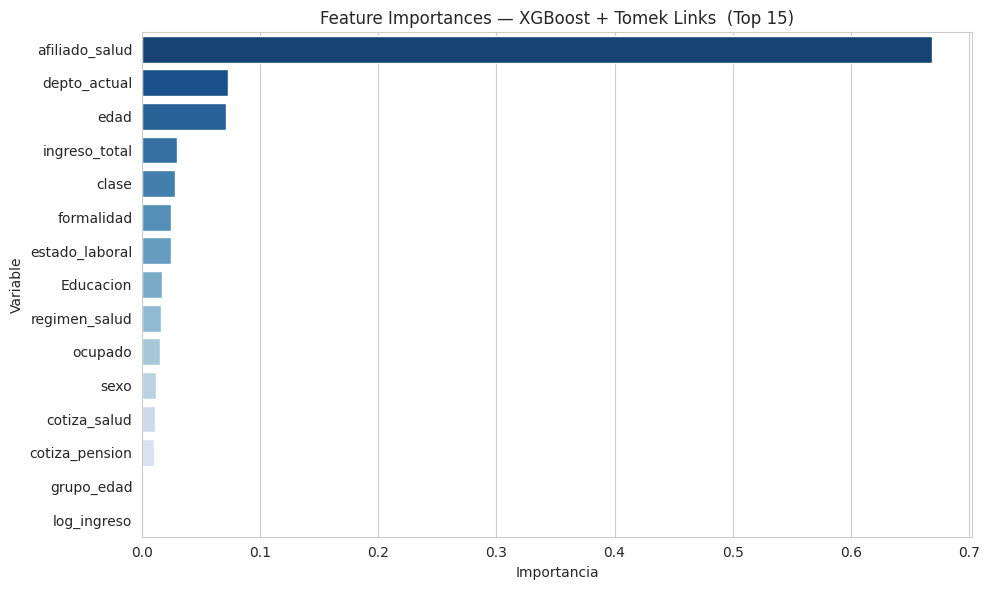


Top 15 variables:
      Variable  Importancia
afiliado_salud     0.669076
  depto_actual     0.072384
          edad     0.070581
 ingreso_total     0.029380
         clase     0.027791
    formalidad     0.024643
estado_laboral     0.024640
     Educacion     0.017051
 regimen_salud     0.016306
       ocupado     0.015010
          sexo     0.011868
  cotiza_salud     0.011006
cotiza_pension     0.010266
    grupo_edad     0.000000
   log_ingreso     0.000000


In [32]:
FEATURES = X_train_proc.columns.tolist()

if hasattr(modelo_campeon, 'feature_importances_'):
    importancias = pd.DataFrame({
        'Variable':    FEATURES,
        'Importancia': modelo_campeon.feature_importances_
    }).sort_values('Importancia', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias.head(15), x='Importancia', y='Variable', palette='Blues_r')
    plt.title(f'Feature Importances — {CAMPEON}  (Top 15)')
    plt.tight_layout(); plt.show()
    print('\nTop 15 variables:')
    print(importancias.head(15).to_string(index=False))

elif hasattr(modelo_campeon, 'coef_'):
    importancias = pd.DataFrame({
        'Variable':    FEATURES,
        'Coef':        modelo_campeon.coef_[0],
        'Abs':         np.abs(modelo_campeon.coef_[0])
    }).sort_values('Abs', ascending=False)

    plt.figure(figsize=(10, 6))
    colores = ['#e53935' if c > 0 else '#1e88e5' for c in importancias.head(15)['Coef']]
    plt.barh(importancias.head(15)['Variable'][::-1],
             importancias.head(15)['Abs'][::-1], color=colores[::-1])
    plt.title(f'Coeficientes (|valor|) — {CAMPEON}  (Top 15)')
    plt.xlabel('|Coeficiente|')
    plt.tight_layout(); plt.show()
    print('\nTop 15 coeficientes:')
    print(importancias.head(15)[['Variable','Coef','Abs']].to_string(index=False))

Calculando valores SHAP (muestra 5 000 obs.)...


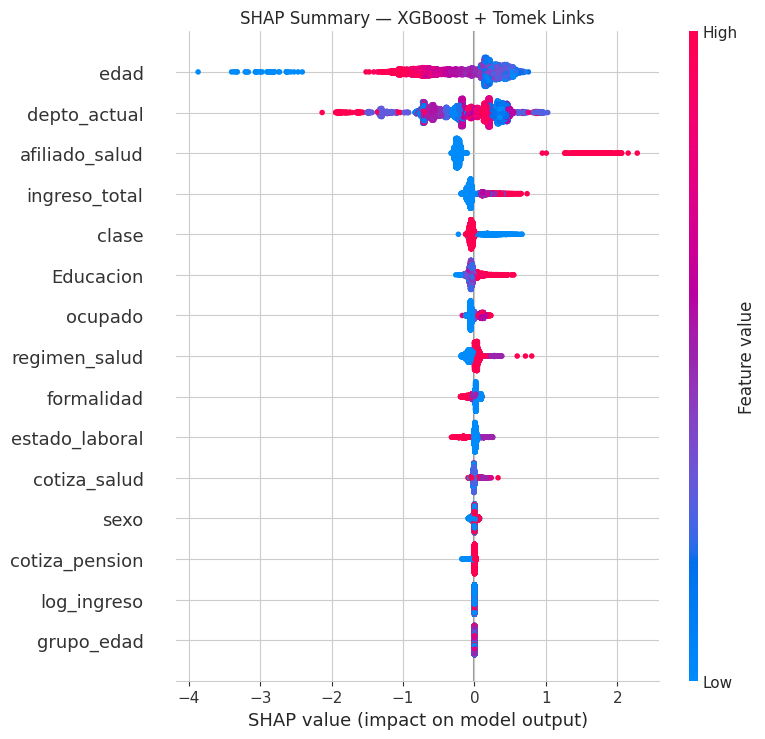

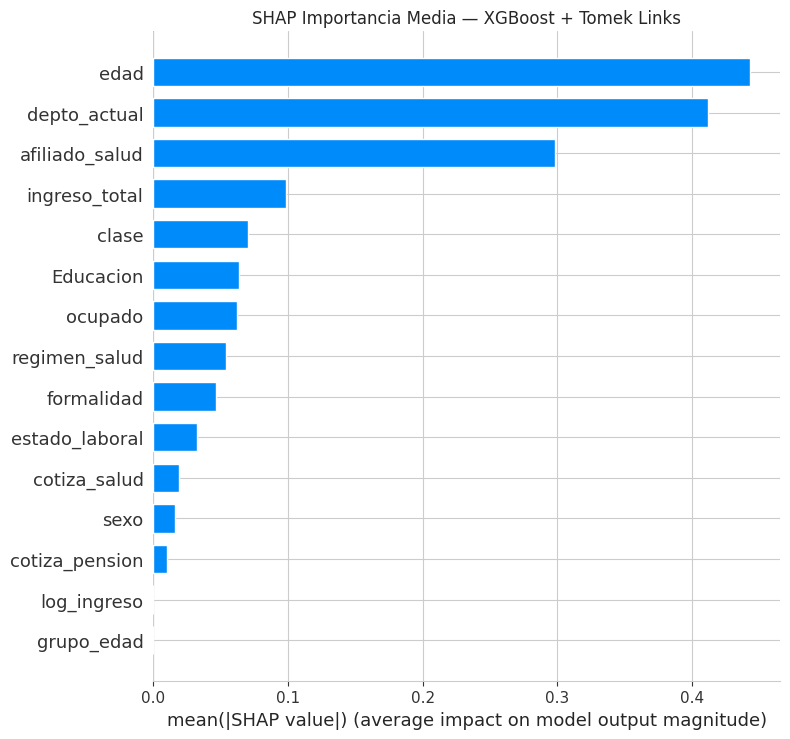

✔ Análisis SHAP completado.


In [33]:
print('Calculando valores SHAP (muestra 5 000 obs.)...')
N_SHAP = min(5_000, len(X_train_proc))
X_shap = X_train_proc.sample(n=N_SHAP, random_state=42)

tree_models = (XGBClassifier, RandomForestClassifier, DecisionTreeClassifier)

if isinstance(modelo_campeon, tree_models):
    explainer   = shap.TreeExplainer(modelo_campeon)
    shap_values = explainer.shap_values(X_shap)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer   = shap.LinearExplainer(modelo_campeon, X_shap)
    shap_vals   = explainer.shap_values(X_shap)
plt.figure()
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURES, show=False)
plt.title(f'SHAP Summary — {CAMPEON}')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURES, plot_type='bar', show=False)
plt.title(f'SHAP Importancia Media — {CAMPEON}')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

del X_shap, shap_vals; gc.collect()
print('✔ Análisis SHAP completado.')

In [34]:
importancias.to_csv('importancias_modelo_campeon.csv', index=False)
df_migrantes_pred.to_csv('migrantes_test_con_destino.csv', index=False)

print('Archivos exportados:')
print('  ✔ importancias_modelo_campeon.csv')
print('  ✔ migrantes_test_con_destino.csv')
print('  ✔ diagnostico_final.png')
print('  ✔ shap_summary.png')
print('  ✔ shap_bar.png')
print(f'\n🏆 Modelo campeón   : {CAMPEON}')
print(f'   ROC-AUC CV       : {BEST_SCORE_CV:.4f}')
print(f'   Umbral óptimo    : {THRESHOLD:.4f}')
print(f'   Recall (test)    : {rec:.4f}')
print(f'   Precision (test) : {prec:.4f}')
print(f'   F1 (test)        : {f1:.4f}')
print(f'   ROC-AUC (test)   : {roc:.4f}')
print(f'   PR-AUC (test)    : {prauc:.4f}')

Archivos exportados:
  ✔ importancias_modelo_campeon.csv
  ✔ migrantes_test_con_destino.csv
  ✔ diagnostico_final.png
  ✔ shap_summary.png
  ✔ shap_bar.png

🏆 Modelo campeón   : XGBoost + Tomek Links
   ROC-AUC CV       : 0.7480
   Umbral óptimo    : 0.4541
   Recall (test)    : 0.7469
   Precision (test) : 0.0498
   F1 (test)        : 0.0934
   ROC-AUC (test)   : 0.7663
   PR-AUC (test)    : 0.1102


## 💾 11. Checkpoint — Guardar resultados en Drive

> Guarda los resultados del análisis en Drive para poder correr el K-Prototypes y los mapas en una sesión nueva sin re-entrenar los modelos.

In [35]:
RUTA_CHECKPOINT = "/content/drive/MyDrive/GEIH/GEIH_Predicciones_Test.csv"

df_migrantes_pred.to_csv(RUTA_CHECKPOINT, index=False, sep=';', encoding='latin-1')

print(f'✔ Checkpoint guardado: {RUTA_CHECKPOINT}')
print(f'  Migrantes en test con destino predicho: {len(df_migrantes_pred):,}')
print(f'  Columnas: {list(df_migrantes_pred.columns)}')
print()
print('Vista previa de la base guardada:')
df_migrantes_pred.head()

✔ Checkpoint guardado: /content/drive/MyDrive/GEIH/GEIH_Predicciones_Test.csv
  Migrantes en test con destino predicho: 259,858
  Columnas: ['directorio', 'secuencia_p', 'orden', 'edad', 'sexo', 'depto_actual', 'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'Educacion', 'clase', 'mes', 'ocupado', 'migro_12m', 'depto_12m', 'mpio_12m', 'depto_anterior', 'razon_migracion', 'ingreso_principal', 'recibe_horas_extra', 'valor_horas_extra', 'horas_extra_incluidas', 'cotiza_pension', 'ano', 'ingreso_total', 'log_ingreso', 'target_migro', 'grupo_edad', 'formalidad', 'estado_laboral', '_orig_idx', 'depto_destino_pred', 'destino_top1', 'destino_top2', 'destino_top3', 'prob_destino_top1']

Vista previa de la base guardada:


,directorio,secuencia_p,orden,edad,sexo,depto_actual,afiliado_salud,regimen_salud,cotiza_salud,Educacion,...,target_migro,grupo_edad,formalidad,estado_laboral,_orig_idx,depto_destino_pred,destino_top1,destino_top2,destino_top3,prob_destino_top1
0,8378529,1,2,49,0,63,1,3.0,2.0,3.0,...,0,4,0,1.0,3233971,17,17,5,18,0.076586
1,8211136,1,1,24,1,66,1,1.0,3.0,9.0,...,0,2,2,1.0,2889738,11,11,5,50,0.131010
2,7364950,1,1,30,0,18,1,3.0,2.0,5.0,...,0,3,2,1.0,1061158,11,11,5,76,0.110195
3,8342086,1,1,57,1,76,1,1.0,1.0,1.0,...,0,4,1,1.0,3147527,50,50,5,63,0.247903
4,8144085,1,2,42,0,15,1,1.0,5.0,8.0,...,0,3,0,1.0,2745023,11,11,5,76,0.185275


### ▶ Opción: cargar checkpoint (sin re-entrenar modelos)

> Si ya corriste todo anteriormente, ejecuta **solo esta celda** y salta directo al Paso 12 (K-Prototypes) o al 13 (Mapas).

In [36]:
MAPA_DEPTOS_GEO = {
     5:'Antioquia',  8:'Atlántico', 11:'Bogotá',    13:'Bolívar',
    15:'Boyacá',    17:'Caldas',    18:'Caquetá',   19:'Cauca',
    20:'Cesar',     23:'Córdoba',   25:'Cundinamarca',27:'Chocó',
    41:'Huila',     44:'La Guajira',47:'Magdalena', 50:'Meta',
    52:'Nariño',    54:'N. Santander',63:'Quindío', 66:'Risaralda',
    68:'Santander', 70:'Sucre',     73:'Tolima',    76:'Valle',
    81:'Arauca',    85:'Casanare',  86:'Putumayo',  88:'San Andrés',
    91:'Amazonas',  94:'Guainía',   95:'Guaviare',  97:'Vaupés', 99:'Vichada',
}

RUTA_CHECKPOINT = "/content/drive/MyDrive/GEIH/GEIH_Predicciones_Test.csv"
df_migrantes_pred = pd.read_csv(RUTA_CHECKPOINT, sep=';', encoding='latin-1', low_memory=False)

if 'grupo_edad' not in df_migrantes_pred.columns:
    df_migrantes_pred['grupo_edad'] = pd.to_numeric(df_migrantes_pred.get('edad'), errors='coerce').apply(
        lambda x: 1 if x<=18 else 2 if x<=25 else 3 if x<=45 else 4 if x<=60 else 5)
if 'ingreso_total' not in df_migrantes_pred.columns:
    df_migrantes_pred['ingreso_total'] = 0

print(f'✔ Checkpoint cargado desde: {RUTA_CHECKPOINT}')
print(f'  {len(df_migrantes_pred):,} migrantes con destino predicho')
print(f'  Columnas: {list(df_migrantes_pred.columns)}')
print()
print('Vista previa:')
df_migrantes_pred.head()

✔ Checkpoint cargado desde: /content/drive/MyDrive/GEIH/GEIH_Predicciones_Test.csv
  259,858 migrantes con destino predicho
  Columnas: ['directorio', 'secuencia_p', 'orden', 'edad', 'sexo', 'depto_actual', 'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'Educacion', 'clase', 'mes', 'ocupado', 'migro_12m', 'depto_12m', 'mpio_12m', 'depto_anterior', 'razon_migracion', 'ingreso_principal', 'recibe_horas_extra', 'valor_horas_extra', 'horas_extra_incluidas', 'cotiza_pension', 'ano', 'ingreso_total', 'log_ingreso', 'target_migro', 'grupo_edad', 'formalidad', 'estado_laboral', '_orig_idx', 'depto_destino_pred', 'destino_top1', 'destino_top2', 'destino_top3', 'prob_destino_top1']

Vista previa:


,directorio,secuencia_p,orden,edad,sexo,depto_actual,afiliado_salud,regimen_salud,cotiza_salud,Educacion,...,target_migro,grupo_edad,formalidad,estado_laboral,_orig_idx,depto_destino_pred,destino_top1,destino_top2,destino_top3,prob_destino_top1
0,8378529,1,2,49,0,63,1,3.0,2.0,3.0,...,0,4,0,1.0,3233971,17,17,5,18,0.076586
1,8211136,1,1,24,1,66,1,1.0,3.0,9.0,...,0,2,2,1.0,2889738,11,11,5,50,0.131010
2,7364950,1,1,30,0,18,1,3.0,2.0,5.0,...,0,3,2,1.0,1061158,11,11,5,76,0.110195
3,8342086,1,1,57,1,76,1,1.0,1.0,1.0,...,0,4,1,1.0,3147527,50,50,5,63,0.247903
4,8144085,1,2,42,0,15,1,1.0,5.0,8.0,...,0,3,0,1.0,2745023,11,11,5,76,0.185275


## 🗂️ 12. Clustering K-Prototypes — Perfiles de migrantes con destino



In [37]:
# ── CHUNK 1: Cargar y preparar solo migrantes reales ─────────────────────────
DEPTOS_VALIDOS = {5,8,11,13,15,17,18,19,20,23,25,27,41,44,47,50,52,54,
                  63,66,68,70,73,76,81,85,86,88,91,94,95,97,99}
MAPA_DEPTOS_GEO = {
     5:'Antioquia',  8:'Atlántico', 11:'Bogotá',     13:'Bolívar',
    15:'Boyacá',    17:'Caldas',    18:'Caquetá',    19:'Cauca',
    20:'Cesar',     23:'Córdoba',   25:'Cundinamarca',27:'Chocó',
    41:'Huila',     44:'La Guajira',47:'Magdalena',  50:'Meta',
    52:'Nariño',    54:'N. Santander',63:'Quindío',  66:'Risaralda',
    68:'Santander', 70:'Sucre',     73:'Tolima',     76:'Valle del Cauca',
    81:'Arauca',    85:'Casanare',  86:'Putumayo',   88:'San Andrés',
    91:'Amazonas',  94:'Guainía',   95:'Guaviare',   97:'Vaupés', 99:'Vichada',
}
MAPA_RAZON = {
     1:'Trabajo',  2:'Educación',   3:'Salud',        4:'Violencia',
     5:'Inseguridad', 6:'Desastre', 7:'Nuevo hogar',  8:'Acomp. familiar',
     9:'Cultural', 10:'Vivienda',  11:'No identificado', 12:'Otro', -1:'Sin dato',
}

df_raw = pd.read_csv(RUTA_PROYECTO, sep=';', encoding='latin-1', low_memory=False)
for col in ['edad','ingreso_principal','valor_horas_extra','ocupado',
            'cotiza_salud','cotiza_pension','afiliado_salud','migro_12m',
            'depto_actual','depto_12m','razon_migracion','Educacion','sexo','clase']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw['ingreso_total'] = df_raw['ingreso_principal'].fillna(0) + df_raw['valor_horas_extra'].fillna(0)
df_raw['log_ingreso']   = np.log1p(df_raw['ingreso_total'])
df_raw['sexo']          = df_raw['sexo'].map({1:'Hombre', 2:'Mujer'})
df_raw['clase']         = df_raw['clase'].map({1:'Urbano', 0:'Rural'})
df_raw['Educacion']     = df_raw['Educacion'].replace(99, np.nan)
df_raw['grupo_edad']    = df_raw['edad'].apply(
    lambda x: np.nan if pd.isna(x) else
    ('0-18' if x<=18 else '19-25' if x<=25 else '26-45' if x<=45 else '46-60' if x<=60 else '60+'))
df_raw['formalidad']    = df_raw.apply(
    lambda r: 'No ocupado' if r['ocupado']!=1 else (
        'Formal'      if r['cotiza_salud']==1 and r['cotiza_pension']==1 else
        'Parc.formal' if r['cotiza_salud']!=r['cotiza_pension'] else
        'Informal'    if r['cotiza_salud']==2 else 'No ocupado'), axis=1)
df_raw['estado_laboral']  = df_raw['ocupado'].map({1:'Ocupado', 2:'Desocupado', 3:'Inactivo'})
df_raw['razon_migracion'] = df_raw['razon_migracion'].fillna(-1).astype(int)
df_raw['depto_origen_nom']= df_raw['depto_actual'].map(MAPA_DEPTOS_GEO)
df_raw['depto_destino_nom']= df_raw['depto_12m'].map(MAPA_DEPTOS_GEO)
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

df_reales = df_raw[
    df_raw['migro_12m'].isin([3, 4]) &
    df_raw['depto_actual'].isin(DEPTOS_VALIDOS) &
    df_raw['depto_12m'].isin(DEPTOS_VALIDOS)
].copy().reset_index(drop=True)
del df_raw; gc.collect()
print(f'✔ Migrantes reales: {len(df_reales):,}')

✔ Migrantes reales: 72,654


  K=2 | Costo=271,745
  K=3 | Costo=218,294
  K=4 | Costo=184,755
  K=5 | Costo=171,521
  K=6 | Costo=154,212
  K=7 | Costo=149,724
  K=8 | Costo=141,496


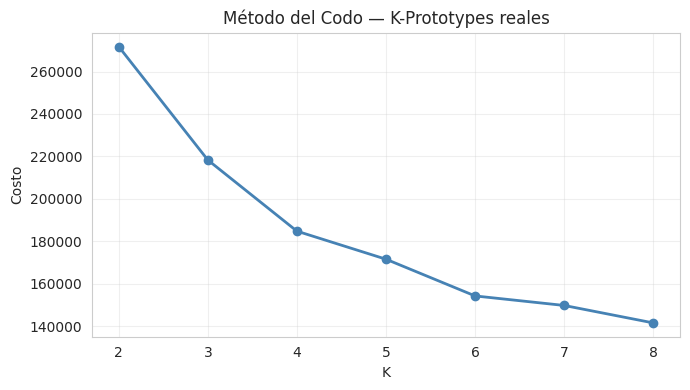


✔ K=6
cluster
0     8031
1    11787
2    12588
3     7407
4    11904
5    20937
Name: count, dtype: int64


In [39]:
# ── CHUNK 2: K-Prototypes ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

NUM_COLS = ['edad', 'log_ingreso', 'Educacion']
CAT_COLS = ['sexo', 'clase', 'grupo_edad', 'formalidad', 'estado_laboral',
            'depto_origen_nom', 'depto_destino_nom']

df_kp = df_reales[NUM_COLS + CAT_COLS + ['razon_migracion']].copy()
for col in NUM_COLS:
    df_kp[col] = df_kp[col].fillna(df_kp[col].median())
for col in CAT_COLS:
    df_kp[col] = df_kp[col].fillna(df_kp[col].mode()[0])
df_kp['razon_migracion'] = df_kp['razon_migracion'].astype(str)
for col in CAT_COLS:
    df_kp[col] = df_kp[col].astype(str)
df_kp = df_kp.dropna().reset_index(drop=True)
df_reales_cl = df_reales.loc[df_kp.index].reset_index(drop=True)

scaler = StandardScaler()
df_kp_scaled = df_kp.copy()
df_kp_scaled[NUM_COLS] = scaler.fit_transform(df_kp[NUM_COLS])
ALL_CATS = CAT_COLS + ['razon_migracion']
cat_idx  = [df_kp_scaled.columns.get_loc(c) for c in ALL_CATS]
X_kp     = df_kp_scaled.values

# Codo
costos = []
for k in range(2, 9):
    m = KPrototypes(n_clusters=k, init='Huang', random_state=42, n_init=3)
    m.fit(X_kp, categorical=cat_idx)
    costos.append(m.cost_)
    print(f'  K={k} | Costo={m.cost_:,.0f}')

plt.figure(figsize=(7,4))
plt.plot(range(2,9), costos, marker='o', color='steelblue', lw=2)
plt.xlabel('K'); plt.ylabel('Costo'); plt.title('Método del Codo — K-Prototypes reales')
plt.xticks(range(2,9)); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

K_OPT = 6
kp = KPrototypes(n_clusters=K_OPT, init='Huang', random_state=42, n_init=5)
df_reales_cl['cluster'] = kp.fit_predict(X_kp, categorical=cat_idx)
print(f'\n✔ K={K_OPT}')
print(df_reales_cl['cluster'].value_counts().sort_index())

In [41]:
# ── CHUNK 3: Perfiles narrativos por cluster ──────────────────────────────────
MAPA_EDU = {
    1:'Ninguno', 2:'Preescolar', 3:'Primaria', 4:'Secundaria',
    5:'Media acad.', 6:'Media téc.', 7:'Normalista', 8:'Técnica prof.',
    9:'Tecnológica', 10:'Universitaria', 11:'Especialización',
    12:'Maestría', 13:'Doctorado',
}

for cl in sorted(df_reales_cl['cluster'].unique()):
    sub = df_reales_cl[df_reales_cl['cluster'] == cl]
    n   = len(sub)
    pct = n / len(df_reales_cl) * 100

    sexo     = sub['sexo'].value_counts(normalize=True).mul(100)
    edad_gr  = sub['grupo_edad'].value_counts(normalize=True).mul(100)
    zona     = sub['clase'].value_counts(normalize=True).mul(100)
    laboral  = sub['estado_laboral'].value_counts(normalize=True).mul(100)
    formal   = sub['formalidad'].value_counts(normalize=True).mul(100)
    edu_mode = MAPA_EDU.get(int(sub['Educacion'].mode()[0]) if sub['Educacion'].notna().any() else 0, '-')
    edad_med = sub['edad'].median()

    tiene_ingreso = (sub['log_ingreso'] > 0).mean() * 100
    ingreso       = np.expm1(sub.loc[sub['log_ingreso'] > 0, 'log_ingreso'].median())
    ingreso_str   = f'${ingreso:,.0f} (reporta {tiene_ingreso:.0f}%)' if tiene_ingreso > 5 else 'No reporta ingreso laboral'

    razones  = sub['razon_migracion'].map(MAPA_RAZON)
    razones  = razones[razones != 'Sin dato'].value_counts(normalize=True).mul(100)

    origen   = sub['depto_origen_nom'].value_counts(normalize=True).mul(100)
    destino  = sub['depto_destino_nom'].value_counts(normalize=True).mul(100)

    print(f'\n{"═"*65}')
    print(f'  CLUSTER {cl}  —  {n:,} personas  ({pct:.1f}% del total)')
    print(f'{"═"*65}')
    print(f'  Quiénes son     : {sexo.index[0]} ({sexo.iloc[0]:.0f}%)  |  '
          f'{edad_gr.index[0]} años ({edad_gr.iloc[0]:.0f}%)  |  '
          f'{zona.index[0]} ({zona.iloc[0]:.0f}%)')
    print(f'  Mercado laboral : {" | ".join([f"{k} {v:.0f}%" for k,v in laboral.head(2).items()])}')
    print(f'  Protec. social  : {" | ".join([f"{k} {v:.0f}%" for k,v in formal.head(2).items()])}')
    print(f'  Educación       : {edu_mode}  |  Edad mediana: {edad_med:.0f} años  |  Ingreso: {ingreso_str}')

    print(f'  Por qué migró:')
    for razon, p in razones.head(3).items():
        barra = '▓' * int(p / 4)
        print(f'    {razon:<22}  {p:5.1f}%  {barra}')

    print(f'  De dónde sale   :  ' +
          '  |  '.join([f'{d} {p:.0f}%' for d, p in origen.head(3).items()]))
    print(f'  A dónde va      :  ' +
          '  |  '.join([f'{d} {p:.0f}%' for d, p in destino.head(3).items()]))

print(f'\n{"═"*65}')


═════════════════════════════════════════════════════════════════
  CLUSTER 0  —  8,031 personas  (11.1% del total)
═════════════════════════════════════════════════════════════════
  Quiénes son     : Mujer (61%)  |  46-60 años (52%)  |  Urbano (100%)
  Mercado laboral : Ocupado 78% | Desocupado 22%
  Protec. social  : No ocupado 79% | Parc.formal 21%
  Educación       : Primaria  |  Edad mediana: 60 años  |  Ingreso: No reporta ingreso laboral
  Por qué migró:
    Acomp. familiar          39.5%  ▓▓▓▓▓▓▓▓▓
    Salud                    21.2%  ▓▓▓▓▓
    Trabajo                  18.6%  ▓▓▓▓
  De dónde sale   :  Meta 9%  |  Antioquia 8%  |  Caldas 7%
  A dónde va      :  Bogotá 14%  |  Antioquia 10%  |  Valle del Cauca 8%

═════════════════════════════════════════════════════════════════
  CLUSTER 1  —  11,787 personas  (16.2% del total)
═════════════════════════════════════════════════════════════════
  Quiénes son     : Hombre (66%)  |  26-45 años (50%)  |  Urbano (100%)
  Mercado labo

## 🗺️ 13. Mapas de calor — Colombia por departamento



In [51]:
!wget -q https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_COL_shp.zip
!unzip -oq gadm41_COL_shp.zip
gdf = gpd.read_file("gadm41_COL_1.shp")
print('✔ Shapefile cargado:', gdf.shape)

✔ Shapefile cargado: (33, 12)


In [59]:

origen_real  = df_reales['depto_actual'].map(MAPA_DEPTOS_GEO).value_counts().reset_index()
origen_real.columns  = ['depto', 'n_salen_real']

destino_real = df_reales['depto_12m'].map(MAPA_DEPTOS_GEO).value_counts().reset_index()
destino_real.columns = ['depto', 'n_llegan_real']

origen_pred  = df_migrantes_pred['depto_actual'].map(MAPA_DEPTOS_GEO).value_counts().reset_index()
origen_pred.columns  = ['depto', 'n_salen_pred']

destino_pred = df_migrantes_pred['depto_destino_pred'].astype(float).astype('Int64').map(MAPA_DEPTOS_GEO).value_counts().reset_index()
destino_pred.columns = ['depto', 'n_llegan_pred']

GADM_NORM = {
    'Bogotá':'Bogotá D.C.', 'N. Santander':'Norte de Santander',
    'Valle del Cauca':'Valle del Cauca', 'San Andrés':'Archipiélago de San Andrés',
}
for df_ in [origen_real, destino_real, origen_pred, destino_pred]:
    df_['depto'] = df_['depto'].astype(str).replace(GADM_NORM)

gdf_map = gdf[['NAME_1','geometry']].rename(columns={'NAME_1':'depto'})
gdf_map['depto'] = gdf_map['depto'].astype(str)

gdf_map = (gdf_map
           .merge(origen_real,  on='depto', how='left')
           .merge(destino_real, on='depto', how='left')
           .merge(origen_pred,  on='depto', how='left')
           .merge(destino_pred, on='depto', how='left'))

print('✔ Flujos preparados')
print(f'  Migrantes reales   : {df_reales.shape[0]:,}')
print(f'  Migrantes predichos: {df_migrantes_pred.shape[0]:,}')
print(f'\n  Columnas gdf_map: {list(gdf_map.columns)}')
print(f'  Departamentos sin match: {gdf_map[gdf_map["n_salen_real"].isna()]["depto"].tolist()}')

✔ Flujos preparados
  Migrantes reales   : 72,654
  Migrantes predichos: 259,858

  Columnas gdf_map: ['depto', 'geometry', 'n_salen_real', 'n_llegan_real', 'n_salen_pred', 'n_llegan_pred']
  Departamentos sin match: ['San Andrés y Providencia']


In [61]:
gdf_map['n_llegan_pred_log'] = np.log1p(gdf_map['n_llegan_pred'])

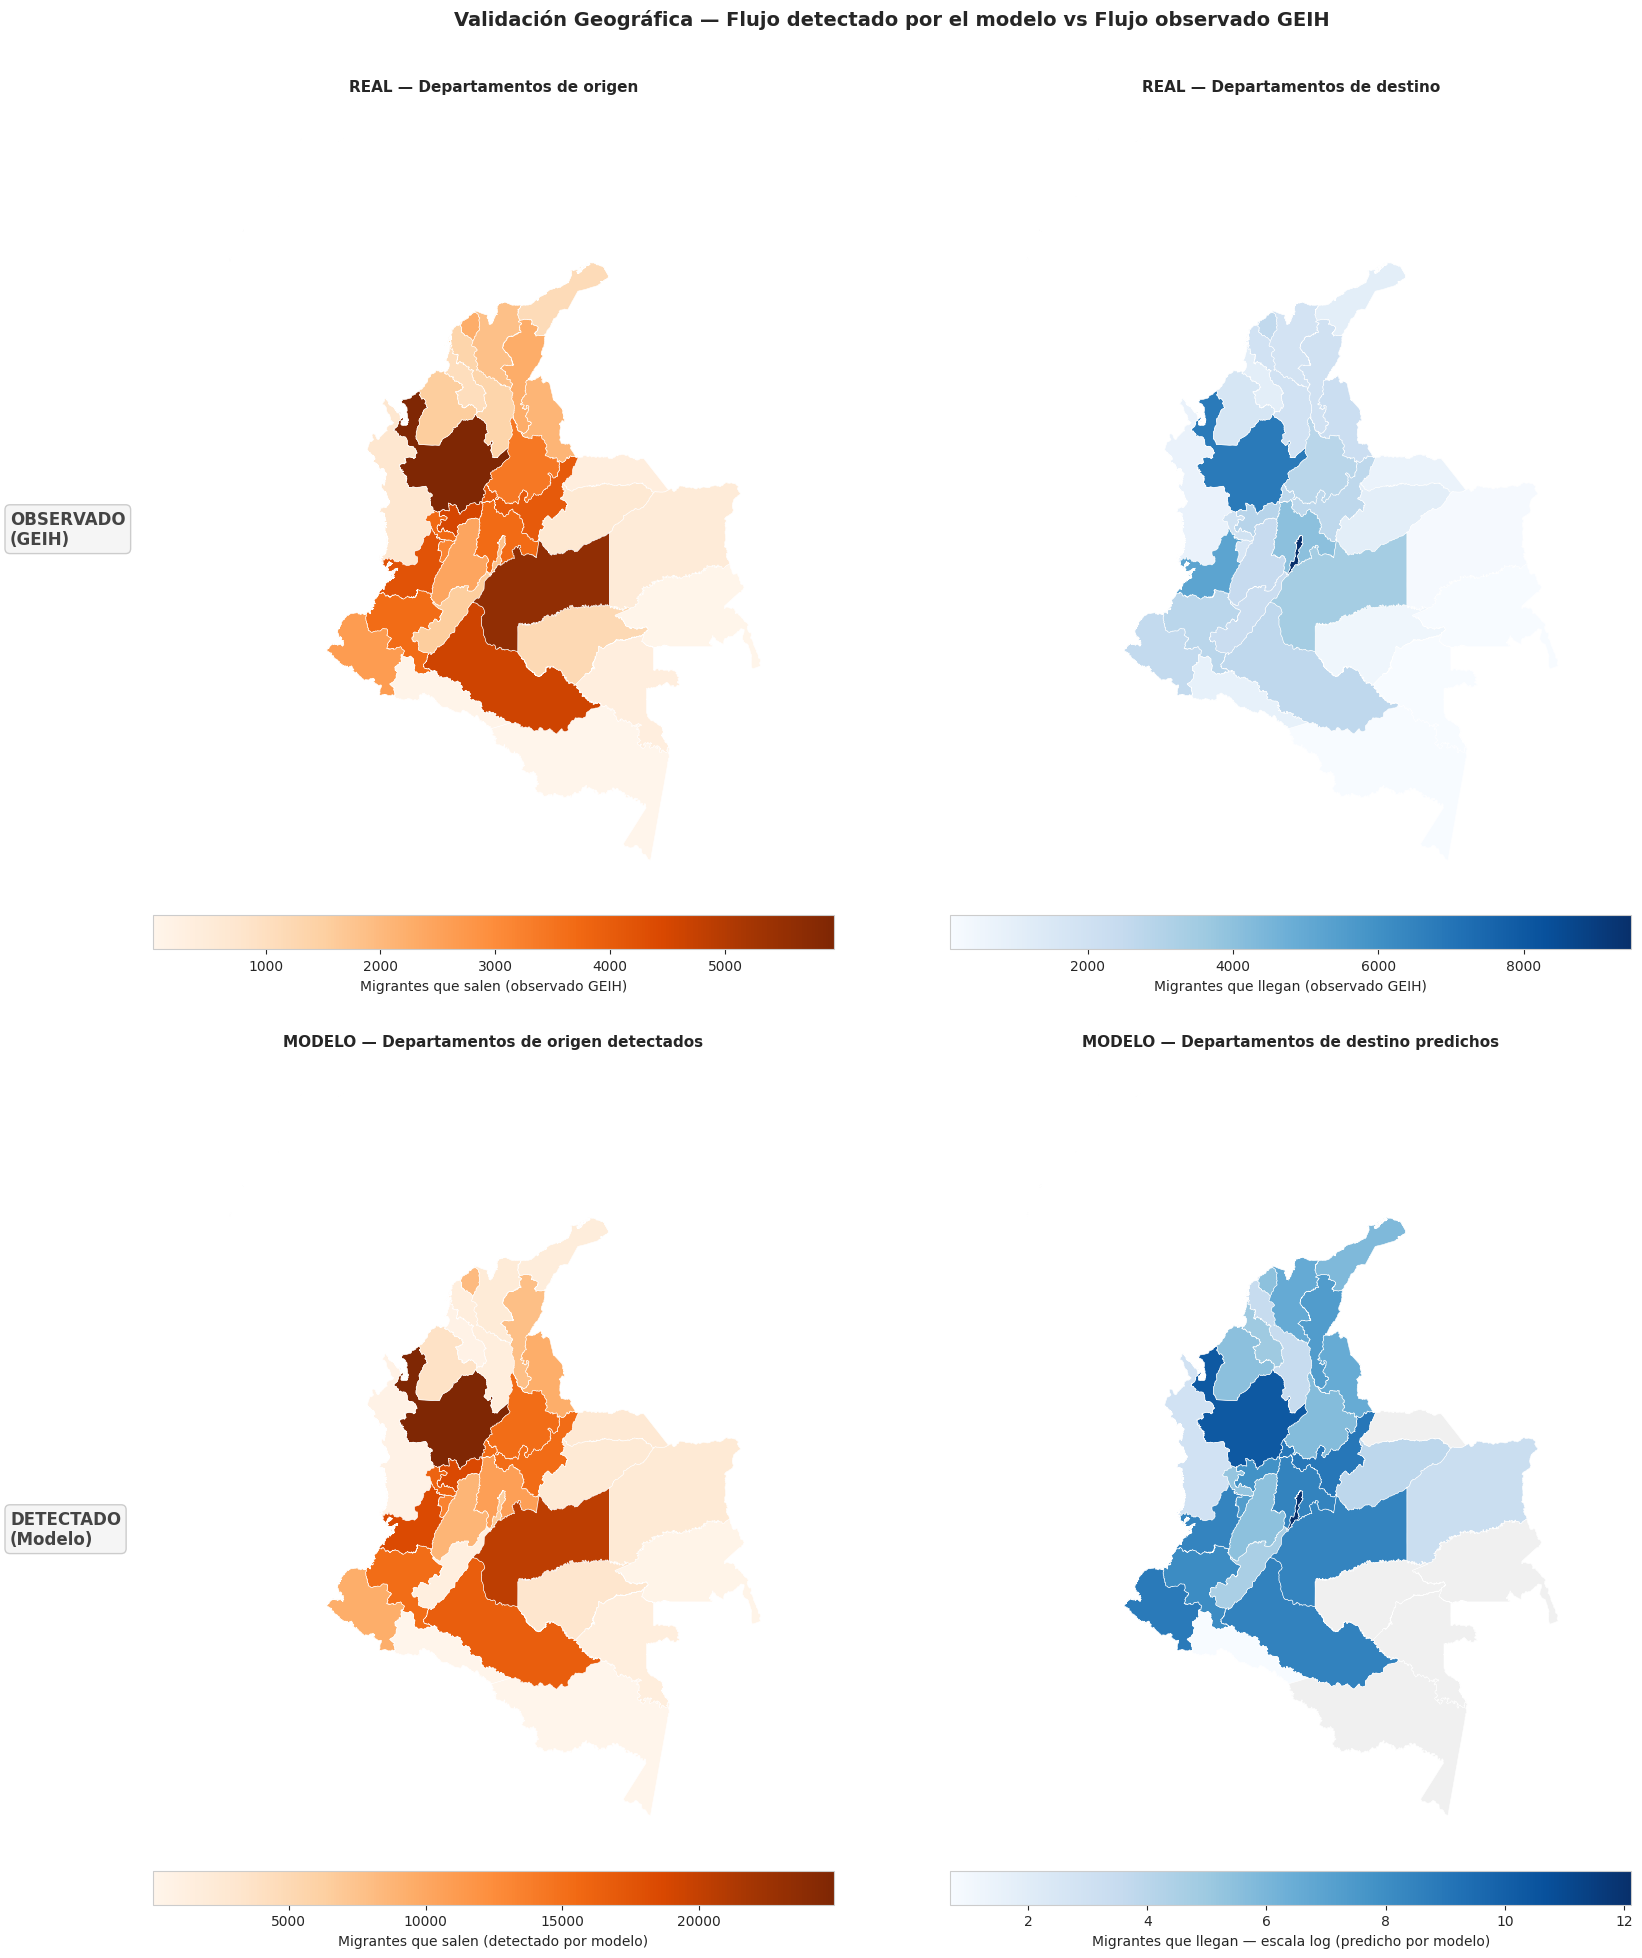

✔ Guardado: validacion_geografica_modelo.png


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(18, 20))
fig.suptitle('Validación Geográfica — Flujo detectado por el modelo vs Flujo observado GEIH',
             fontsize=14, fontweight='bold', y=1.01)

mapas = [
    (axes[0,0], 'n_salen_real',  'Oranges', 'REAL — Departamentos de origen',
     'Migrantes que salen (observado GEIH)'),
    (axes[0,1], 'n_llegan_real', 'Blues',   'REAL — Departamentos de destino',
     'Migrantes que llegan (observado GEIH)'),
    (axes[1,0], 'n_salen_pred',  'Oranges', 'MODELO — Departamentos de origen detectados',
     'Migrantes que salen (detectado por modelo)'),
    (axes[1,1], 'n_llegan_pred_log', 'Blues', 'MODELO — Departamentos de destino predichos',
 'Migrantes que llegan — escala log (predicho por modelo)'),
]

for ax, col, cmap, titulo, label_cbar in mapas:
    if gdf_map[col].notna().sum() == 0:
        ax.set_title(f'{titulo}\n(sin datos)', fontsize=11)
        ax.axis('off')
        continue
    gdf_map.plot(
        column=col, cmap=cmap, linewidth=0.4, edgecolor='white',
        legend=True, ax=ax,
        missing_kwds={'color':'#f0f0f0', 'label':'Sin datos'},
        legend_kwds={'label': label_cbar, 'orientation':'horizontal',
                     'shrink':0.7, 'pad':0.02}
    )
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

for row, label in zip([0, 1], ['OBSERVADO\n(GEIH)', 'DETECTADO\n(Modelo)']):
    fig.text(0.01, 0.75 - row*0.5, label, fontsize=12, fontweight='bold',
             va='center', color='#444444',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', edgecolor='#cccccc'))

plt.tight_layout()
plt.savefig('validacion_geografica_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔ Guardado: validacion_geografica_modelo.png')

In [63]:
# ── Tabla comparativa Top 10 destinos Real vs Modelo ─────────────────────────
top_real  = (df_reales['depto_12m']
             .map(MAPA_DEPTOS_GEO)
             .value_counts(normalize=True)
             .mul(100)
             .head(10)
             .reset_index())
top_real.columns = ['Departamento', 'Real (%)']

top_pred  = (df_migrantes_pred['depto_destino_pred']
             .astype(float).astype('Int64')
             .map(MAPA_DEPTOS_GEO)
             .value_counts(normalize=True)
             .mul(100)
             .head(10)
             .reset_index())
top_pred.columns = ['Departamento', 'Modelo (%)']

df_comp = top_real.merge(top_pred, on='Departamento', how='outer').fillna(0)
df_comp['Real (%)']   = df_comp['Real (%)'].round(1)
df_comp['Modelo (%)'] = df_comp['Modelo (%)'].round(1)
df_comp['Diferencia (pp)'] = (df_comp['Modelo (%)'] - df_comp['Real (%)']).round(1)
df_comp = df_comp.sort_values('Real (%)', ascending=False).reset_index(drop=True)
df_comp.index += 1

print('═'*55)
print('  TOP 10 DESTINOS — Real (GEIH) vs Modelo')
print('═'*55)
print(df_comp.to_string())
print('═'*55)

═══════════════════════════════════════════════════════
  TOP 10 DESTINOS — Real (GEIH) vs Modelo
═══════════════════════════════════════════════════════
       Departamento  Real (%)  Modelo (%)  Diferencia (pp)
1            Bogotá      13.0        70.5             57.5
2         Antioquia       9.4        11.7              2.3
3   Valle del Cauca       7.2         1.7             -5.5
4      Cundinamarca       5.6         1.9             -3.7
5              Meta       4.7         1.8             -2.9
6            Caldas       4.0         1.0             -3.0
7         Santander       3.9         0.0             -3.9
8             Cauca       3.9         1.3             -2.6
9            Boyacá       3.7         3.0             -0.7
10          Caquetá       3.7         1.9             -1.8
11           Nariño       0.0         2.8              2.8
═══════════════════════════════════════════════════════
